# MobileNetV3-Large · EfficientNet-B0 · Swin-Tiny — Food-101 (8-Class Subset)
**Deep Learning Project** | Module Leader: Dr. Andreas Pester


| Model | V1 (head only) | V2 (intermediate) | V3 (larger unfreeze) |
|---|---|---|---|
| MobileNetV3-Large | classifier only | features[-3:] + classifier | features[-6:] + Dropout(0.3) + classifier |
| EfficientNet-B0 | classifier only | features[8] + classifier | features[6,7,8] + Dropout(0.25) + classifier |
| Swin-Tiny | head only | norm + head | layers[3] + norm + head |


## 0 · Setup

In [1]:
!pip install torch torchvision scikit-learn matplotlib seaborn timm -q

In [2]:
# Upload preprocessing.py when prompted
from google.colab import files
uploaded = files.upload()

Saving preprocessing.py to preprocessing.py


In [3]:
import os, sys, time, copy, warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import timm
from torchvision import models
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
    accuracy_score,
)

# ── Load preprocessing (Colab uploads to /content) ────────────────────────
sys.path.insert(0, '/content')
if 'preprocessing' in sys.modules:
    del sys.modules['preprocessing']
from preprocessing import (
    get_data_loaders,
    get_class_names,
    NUM_CLASSES,
)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'  GPU: {torch.cuda.get_device_name(0)}')
    print(f'  Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

Using device: cuda
  GPU: Tesla T4
  Memory: 15.6 GB


## 1 · Constants

In [4]:
CLASS_NAMES  = get_class_names()
BATCH_SIZE   = 64
IMG_SIZE     = 224
WEIGHT_DECAY = 1e-4
PATIENCE     = 5

# ── Per-variation learning rates ──────────────────────────────────────────
# V1: head-only — keep 1e-3 (fast convergence is fine for tiny param count)
# V2: moderate unfreeze — lowered to 3e-4 to reduce train-val gap
# V3: large unfreeze — keep 1e-4; stronger weight decay applied per model
LR_V1 = 1e-3
LR_V2 = 3e-4   # reduced from 5e-4 to control overfitting in V2
LR_V3 = 1e-4

EPOCHS_V1 = 25
EPOCHS_V2 = 25
EPOCHS_V3 = 25

print(f'Classes : {CLASS_NAMES}')
print(f'Num classes: {NUM_CLASSES}')
print(f'LR → V1: {LR_V1}  V2: {LR_V2}  V3: {LR_V3}')

Classes : ['pizza', 'sushi', 'steak', 'ice_cream', 'french_fries', 'miso_soup', 'bread_pudding', 'caesar_salad']
Num classes: 8
LR → V1: 0.001  V2: 0.0003  V3: 0.0001


## 2 · Data Loaders
Reusing the shared preprocessing pipeline (ImageNet normalisation — baseline winner).

In [5]:
train_loader, val_loader, test_loader, _ = get_data_loaders(
    data_dir='./data',
    batch_size=BATCH_SIZE,
    num_workers=2,
    img_size=IMG_SIZE,
)

100%|██████████| 5.00G/5.00G [03:42<00:00, 22.4MB/s]


Food-101 Dataset Summary (8-Class Subset)
  Selected classes:  ['pizza', 'sushi', 'steak', 'ice_cream', 'french_fries', 'miso_soup', 'bread_pudding', 'caesar_salad']
  Image size:        224x224
  Number of classes: 8
  Training samples:  5400
  Validation samples:600
  Test samples:      2000
  Batch size:        64
  Augmentation:      Standard


## 3 · Shared Helper Functions

In [6]:
# ── Freeze / Unfreeze ────────────────────────────────────────────────────

def freeze_all(model):
    """Freeze every parameter in the model."""
    for param in model.parameters():
        param.requires_grad = False


def unfreeze_modules(module_list):
    """Unfreeze all parameters in a list of nn.Module objects."""
    for module in module_list:
        for param in module.parameters():
            param.requires_grad = True


def count_trainable_params(model):
    """Return (trainable_params, total_params)."""
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total     = sum(p.numel() for p in model.parameters())
    return trainable, total


def print_param_summary(model, model_name):
    trainable, total = count_trainable_params(model)
    print(f'  {model_name:<40}  trainable: {trainable:>10,}  /  total: {total:>10,}'
          f'  ({100 * trainable / total:.1f}%)')


print('Freeze/unfreeze helpers defined.')

Freeze/unfreeze helpers defined.


In [7]:
# ── Top-k accuracy ───────────────────────────────────────────────────────

def top_k_accuracy(output, target, k=5):
    """Compute top-k accuracy (same as baseline)."""
    with torch.no_grad():
        max_k = min(k, output.size(1))
        _, pred = output.topk(max_k, dim=1, largest=True, sorted=True)
        correct = pred.eq(target.view(-1, 1).expand_as(pred))
        return correct.any(dim=1).float().sum().item()


print('top_k_accuracy defined.')

top_k_accuracy defined.


In [8]:
# ── Train one epoch ──────────────────────────────────────────────────────

def train_one_epoch(model, loader, criterion, optimizer, device):
    """Train for one epoch. Returns avg loss, top-1 acc, top-5 acc."""
    model.train()
    running_loss = 0.0
    top1_correct = 0
    top5_correct = 0
    total = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        top1_correct += (outputs.argmax(dim=1) == labels).sum().item()
        top5_correct += top_k_accuracy(outputs, labels, k=5)
        total        += images.size(0)

    return running_loss / total, top1_correct / total, top5_correct / total


print('train_one_epoch defined.')

train_one_epoch defined.


In [9]:
# ── Evaluate (val / test pass) ───────────────────────────────────────────

@torch.no_grad()
def evaluate(model, loader, criterion, device):
    """Evaluate on a data loader. Returns avg loss, top-1, top-5."""
    model.eval()
    running_loss = 0.0
    top1_correct = 0
    top5_correct = 0
    total = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss    = criterion(outputs, labels)

        running_loss += loss.item() * images.size(0)
        top1_correct += (outputs.argmax(dim=1) == labels).sum().item()
        top5_correct += top_k_accuracy(outputs, labels, k=5)
        total        += images.size(0)

    return running_loss / total, top1_correct / total, top5_correct / total


print('evaluate defined.')

evaluate defined.


In [10]:
# ── Full evaluation (test set — all metrics) ──────────────────────────────

@torch.no_grad()
def full_evaluation(model, loader, device, class_names):
    """Run full evaluation and return all metrics + predictions."""
    model.eval()
    all_preds  = []
    all_labels = []
    all_probs  = []
    total_time    = 0.0
    total_samples = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        if device.type == 'cuda':
            torch.cuda.synchronize()
        start = time.perf_counter()

        outputs = model(images)

        if device.type == 'cuda':
            torch.cuda.synchronize()
        end = time.perf_counter()

        total_time    += (end - start)
        total_samples += images.size(0)

        probs = torch.softmax(outputs, dim=1)
        preds = outputs.argmax(dim=1)

        all_preds.append(preds.cpu())
        all_labels.append(labels.cpu())
        all_probs.append(probs.cpu())

    all_preds  = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels).numpy()
    all_probs  = torch.cat(all_probs).numpy()

    top1_acc = accuracy_score(all_labels, all_preds)

    top5_preds = np.argsort(all_probs, axis=1)[:, -5:]
    top5_acc   = np.mean([all_labels[i] in top5_preds[i]
                           for i in range(len(all_labels))])

    precision, recall, f1, support = precision_recall_fscore_support(
        all_labels, all_preds, average=None,
        labels=list(range(len(class_names)))
    )
    macro_p, macro_r, macro_f1, _ = precision_recall_fscore_support(
        all_labels, all_preds, average='macro'
    )

    cm = confusion_matrix(all_labels, all_preds)

    per_class = {}
    for i, name in enumerate(class_names):
        per_class[name] = {
            'precision': precision[i],
            'recall':    recall[i],
            'f1':        f1[i],
            'support':   int(support[i]),
        }

    inference_time_ms = (total_time / total_samples) * 1000

    return {
        'all_preds':        all_preds,
        'all_labels':       all_labels,
        'all_probs':        all_probs,
        'top1_acc':         top1_acc,
        'top5_acc':         top5_acc,
        'macro_precision':  macro_p,
        'macro_recall':     macro_r,
        'macro_f1':         macro_f1,
        'per_class':        per_class,
        'confusion_matrix': cm,
        'inference_time_ms': inference_time_ms,
        'total_params':     sum(p.numel() for p in model.parameters()),
        'trainable_params': sum(p.numel() for p in model.parameters()
                                if p.requires_grad),
    }


print('full_evaluation defined.')

full_evaluation defined.


In [11]:
# ── Print results (same format as baseline) ───────────────────────────────

def print_results(results, run_name):
    print('=' * 65)
    print(f'  {run_name} — Test Results')
    print('=' * 65)
    print(f'  Top-1 Accuracy:      {results["top1_acc"]:.4f}  ({results["top1_acc"]*100:.2f}%)')
    print(f'  Top-5 Accuracy:      {results["top5_acc"]:.4f}  ({results["top5_acc"]*100:.2f}%)')
    print(f'  Macro Precision:     {results["macro_precision"]:.4f}')
    print(f'  Macro Recall:        {results["macro_recall"]:.4f}')
    print(f'  Macro F1-Score:      {results["macro_f1"]:.4f}')
    print(f'  Inference Time:      {results["inference_time_ms"]:.3f} ms/sample')
    print(f'  Total Parameters:    {results["total_params"]:,}')
    print(f'  Trainable Params:    {results["trainable_params"]:,}')
    print('=' * 65)
    print(f'\n{"Class":<18} {"Precision":>10} {"Recall":>10} {"F1-Score":>10} {"Support":>10}')
    print('-' * 65)
    for name, m in results['per_class'].items():
        print(f'{name:<18} {m["precision"]:>10.4f} {m["recall"]:>10.4f}'
              f' {m["f1"]:>10.4f} {m["support"]:>10}')
    print('-' * 65)
    print(f'{"MACRO AVG":<18} {results["macro_precision"]:>10.4f}'
          f' {results["macro_recall"]:>10.4f} {results["macro_f1"]:>10.4f}')


print('print_results defined.')

print_results defined.


In [12]:
# ── Plot helpers (same style as baseline) ─────────────────────────────────

def plot_training_curves(history, run_name):
    epochs_range = range(1, len(history['train_loss']) + 1)
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    axes[0].plot(epochs_range, history['train_loss'], 'o-', label='Train', lw=2, ms=4)
    axes[0].plot(epochs_range, history['val_loss'],   's-', label='Val',   lw=2, ms=4)
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
    axes[0].set_title('Loss'); axes[0].legend(); axes[0].grid(True, alpha=0.3)

    axes[1].plot(epochs_range, history['train_top1'], 'o-', label='Train', lw=2, ms=4)
    axes[1].plot(epochs_range, history['val_top1'],   's-', label='Val',   lw=2, ms=4)
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
    axes[1].set_title('Top-1 Accuracy'); axes[1].legend(); axes[1].grid(True, alpha=0.3)

    axes[2].plot(epochs_range, history['train_top5'], 'o-', label='Train', lw=2, ms=4)
    axes[2].plot(epochs_range, history['val_top5'],   's-', label='Val',   lw=2, ms=4)
    axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('Accuracy')
    axes[2].set_title('Top-5 Accuracy'); axes[2].legend(); axes[2].grid(True, alpha=0.3)

    plt.suptitle(f'{run_name} — Training Curves', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()


def plot_confusion_matrix(results, run_name):
    fig, axes = plt.subplots(1, 2, figsize=(18, 7))

    sns.heatmap(results['confusion_matrix'], annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[0])
    axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('True')
    axes[0].set_title('Confusion Matrix (Counts)')

    cm_norm = (results['confusion_matrix'].astype('float') /
               results['confusion_matrix'].sum(axis=1, keepdims=True))
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[1])
    axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('True')
    axes[1].set_title('Confusion Matrix (Normalised)')

    plt.suptitle(f'{run_name} — Confusion Matrix', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()


def plot_per_class_metrics(results, run_name):
    classes   = list(results['per_class'].keys())
    prec_vals = [results['per_class'][c]['precision'] for c in classes]
    rec_vals  = [results['per_class'][c]['recall']    for c in classes]
    f1_vals   = [results['per_class'][c]['f1']        for c in classes]

    x = np.arange(len(classes))
    width = 0.25
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.bar(x - width, prec_vals, width, label='Precision', color='#4C72B0')
    ax.bar(x,         rec_vals,  width, label='Recall',    color='#55A868')
    ax.bar(x + width, f1_vals,   width, label='F1-Score',  color='#C44E52')
    ax.set_xticks(x)
    ax.set_xticklabels(classes, rotation=30, ha='right')
    ax.set_ylabel('Score'); ax.set_title(f'{run_name} — Per-Class Metrics')
    ax.set_ylim(0, 1.05); ax.legend(); ax.grid(True, axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()


print('Plot helpers defined.')

Plot helpers defined.


In [13]:
# ── Main training wrapper ─────────────────────────────────────────────────

def run_training_variation(model, run_name, lr,
                            num_epochs=25, patience=PATIENCE):
    """
    Full training loop for one model variation.
    Uses the global train_loader / val_loader / DEVICE.
    Returns (trained_model, history).
    """
    criterion = nn.CrossEntropyLoss()
    trainable_params = [p for p in model.parameters() if p.requires_grad]
    optimizer = optim.Adam(trainable_params, lr=lr, weight_decay=WEIGHT_DECAY)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer,
                                                      T_max=num_epochs,
                                                      eta_min=1e-6)

    history = {
        'train_loss': [], 'train_top1': [], 'train_top5': [],
        'val_loss':   [], 'val_top1':   [], 'val_top5':   [],
        'lr': [],
    }

    best_val_acc     = 0.0
    best_model_state = None
    epochs_no_improve = 0

    trainable, total = count_trainable_params(model)
    print(f'\n{"=" * 70}')
    print(f'  Training: {run_name}')
    print(f'  Trainable: {trainable:,} / {total:,}  ({100*trainable/total:.1f}%)')
    print(f'  LR: {lr}  |  Epochs: {num_epochs}  |  Patience: {patience}')
    print(f'{"=" * 70}')
    print(f'{"Epoch":>6} | {"Train Loss":>10} {"Train@1":>8} {"Train@5":>8} | '
          f'{"Val Loss":>10} {"Val@1":>8} {"Val@5":>8} | {"LR":>10}')
    print('-' * 95)

    model.to(DEVICE)

    for epoch in range(1, num_epochs + 1):
        train_loss, train_top1, train_top5 = train_one_epoch(
            model, train_loader, criterion, optimizer, DEVICE)
        val_loss, val_top1, val_top5 = evaluate(
            model, val_loader, criterion, DEVICE)

        current_lr = optimizer.param_groups[0]['lr']
        scheduler.step()

        history['train_loss'].append(train_loss)
        history['train_top1'].append(train_top1)
        history['train_top5'].append(train_top5)
        history['val_loss'].append(val_loss)
        history['val_top1'].append(val_top1)
        history['val_top5'].append(val_top5)
        history['lr'].append(current_lr)

        if val_top1 > best_val_acc:
            best_val_acc      = val_top1
            best_model_state  = copy.deepcopy(model.state_dict())
            epochs_no_improve = 0
            marker = ' ★'
        else:
            epochs_no_improve += 1
            marker = ''

        print(f'{epoch:>6} | {train_loss:>10.4f} {train_top1:>8.4f} {train_top5:>8.4f} | '
              f'{val_loss:>10.4f} {val_top1:>8.4f} {val_top5:>8.4f} | '
              f'{current_lr:>10.6f}{marker}')

        if epochs_no_improve >= patience:
            print(f'\nEarly stopping at epoch {epoch}.')
            break

    model.load_state_dict(best_model_state)
    print(f'Best val Top-1: {best_val_acc:.4f}')
    return model, history


print('run_training_variation defined.')

run_training_variation defined.


In [14]:
# ── Checkpoint saver ──────────────────────────────────────────────────────

def save_checkpoint(model, model_name, history, test_results, lr, save_dir='.'):
    """Save checkpoint in the same format as the baseline."""
    trainable, total = count_trainable_params(model)
    checkpoint = {
        'model_name':       model_name,
        'model_state_dict': model.state_dict(),
        'num_classes':      NUM_CLASSES,
        'class_names':      CLASS_NAMES,
        'img_size':         IMG_SIZE,
        'history':          history,
        'test_metrics': {
            'top1_acc':          test_results['top1_acc'],
            'top5_acc':          test_results['top5_acc'],
            'macro_precision':   test_results['macro_precision'],
            'macro_recall':      test_results['macro_recall'],
            'macro_f1':          test_results['macro_f1'],
            'per_class':         test_results['per_class'],
            'confusion_matrix':  test_results['confusion_matrix'].tolist(),
            'inference_time_ms': test_results['inference_time_ms'],
            'total_params':      total,
            'trainable_params':  trainable,
        },
        'hyperparameters': {
            'epochs_trained': len(history['train_loss']),
            'batch_size':     BATCH_SIZE,
            'learning_rate':  lr,
            'weight_decay':   WEIGHT_DECAY,
            'optimizer':      'Adam',
            'scheduler':      'CosineAnnealingLR',
        },
    }
    safe_name = model_name.lower().replace(' ', '_').replace('(', '').replace(')', '').replace('·', '')
    save_path = os.path.join(save_dir, f'{safe_name}.pth')
    torch.save(checkpoint, save_path)
    print(f'Checkpoint saved → {save_path}  ({os.path.getsize(save_path)/1e6:.1f} MB)')
    return save_path


print('save_checkpoint defined.')

save_checkpoint defined.


In [15]:
# ── Full pipeline for one variation ──────────────────────────────────────

def run_full_variation(model, run_name, lr, num_epochs=25):
    """Train + evaluate + save + plot one variation. Returns test_results."""
    model, history = run_training_variation(model, run_name, lr,
                                             num_epochs=num_epochs)
    plot_training_curves(history, run_name)

    print(f'\nRunning full evaluation on test set...')
    test_results = full_evaluation(model, test_loader, DEVICE, CLASS_NAMES)
    print_results(test_results, run_name)
    plot_confusion_matrix(test_results, run_name)
    plot_per_class_metrics(test_results, run_name)

    print('\nClassification Report:')
    print(classification_report(
        test_results['all_labels'], test_results['all_preds'],
        target_names=CLASS_NAMES, digits=4
    ))

    save_checkpoint(model, run_name, history, test_results, lr)

    # Download in Colab
    try:
        from google.colab import files
        safe = run_name.lower().replace(' ', '_').replace('(','').replace(')','').replace('·','')
        files.download(f'{safe}.pth')
    except Exception:
        pass

    return test_results


print('run_full_variation defined.')
print('\nAll shared functions ready. Proceed to model sections.')

run_full_variation defined.

All shared functions ready. Proceed to model sections.


---
## 4 · MobileNetV3-Large
Three fine-tuning variations using torchvision pretrained weights.

In [16]:
# ── MobileNetV3 builders ─────────────────────────────────────────────────
#
# FIXES applied vs original:
#   V1 (unchanged) — head only, LR 1e-3
#   V2 — was: 1 block (+155k params, too small a step)
#        now: last 3 blocks + classifier (~1.8M trainable)
#             LR lowered to 3e-4 for better generalisation
#   V3 — was: 4 blocks, no regularisation (8% train-val gap)
#        now: last 6 blocks + classifier + Dropout(0.3) before head
#             LR 1e-4, weight_decay=5e-4 (set in training call)

def build_mobilenetv3_v1(num_classes=NUM_CLASSES):
    """V1 — Freeze entire feature extractor; train classifier head only."""
    weights = models.MobileNet_V3_Large_Weights.IMAGENET1K_V2
    model   = models.mobilenet_v3_large(weights=weights)
    freeze_all(model)
    in_features = model.classifier[3].in_features
    model.classifier[3] = nn.Linear(in_features, num_classes)
    unfreeze_modules([model.classifier])
    return model


def build_mobilenetv3_v2(num_classes=NUM_CLASSES):
    """V2 — Unfreeze last 3 feature blocks + classifier (was: only 1 block).
    Rationale: 1 block added only 155k params — a negligible step that still
    overfitted. 3 blocks gives a meaningful capacity increase (~1.8M trainable)
    without jumping straight to 81% of the network.
    """
    weights = models.MobileNet_V3_Large_Weights.IMAGENET1K_V2
    model   = models.mobilenet_v3_large(weights=weights)
    freeze_all(model)
    in_features = model.classifier[3].in_features
    model.classifier[3] = nn.Linear(in_features, num_classes)
    # Unfreeze last 3 InvertedResidual blocks + classifier
    unfreeze_modules(list(model.features[-3:]) + [model.classifier])
    return model


def build_mobilenetv3_v3(num_classes=NUM_CLASSES):
    """V3 — Unfreeze last 6 feature blocks + classifier + Dropout(0.3).
    Rationale: original V3 unfroze 4 blocks but had an 8% train-val gap.
    We unfreeze 6 blocks for more capacity, and add Dropout(0.3) before the
    final Linear to regularise the 5,400-sample dataset.
    """
    weights = models.MobileNet_V3_Large_Weights.IMAGENET1K_V2
    model   = models.mobilenet_v3_large(weights=weights)
    freeze_all(model)
    in_features = model.classifier[3].in_features
    # Add Dropout(0.3) before the final Linear for regularisation
    model.classifier[3] = nn.Sequential(
        nn.Dropout(p=0.3),
        nn.Linear(in_features, num_classes),
    )
    unfreeze_modules(list(model.features[-6:]) + [model.classifier])
    return model


# Sanity check — parameter counts
print('MobileNetV3-Large parameter summary (improved variations):')
for label, builder in [('V1 (head only)',      build_mobilenetv3_v1),
                        ('V2 (last 3 blocks)',  build_mobilenetv3_v2),
                        ('V3 (last 6 blocks + dropout)', build_mobilenetv3_v3)]:
    m = builder()
    print_param_summary(m, f'MobileNetV3 {label}')

MobileNetV3-Large parameter summary (improved variations):
Downloading: "https://download.pytorch.org/models/mobilenet_v3_large-5c1a4163.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_large-5c1a4163.pth


100%|██████████| 21.1M/21.1M [00:00<00:00, 156MB/s]


  MobileNetV3 V1 (head only)                trainable:  1,240,328  /  total:  4,212,280  (29.4%)
  MobileNetV3 V2 (last 3 blocks)            trainable:  2,990,568  /  total:  4,212,280  (71.0%)
  MobileNetV3 V3 (last 6 blocks + dropout)  trainable:  4,020,336  /  total:  4,212,280  (95.4%)


### 4.1 · MobileNetV3 — V1 (Head Only)


  Training: MobileNetV3 · V1 (Head Only)
  Trainable: 1,240,328 / 4,212,280  (29.4%)
  LR: 0.001  |  Epochs: 25  |  Patience: 5
 Epoch | Train Loss  Train@1  Train@5 |   Val Loss    Val@1    Val@5 |         LR
-----------------------------------------------------------------------------------------------
     1 |     0.8109   0.7409   0.9760 |     0.5392   0.7933   0.9950 |   0.001000 ★
     2 |     0.5373   0.8244   0.9900 |     0.4967   0.8317   0.9967 |   0.000996 ★
     3 |     0.4766   0.8436   0.9907 |     0.4750   0.8333   0.9967 |   0.000984 ★
     4 |     0.4344   0.8529   0.9950 |     0.4321   0.8667   0.9933 |   0.000965 ★
     5 |     0.3937   0.8637   0.9950 |     0.4337   0.8783   0.9950 |   0.000938 ★
     6 |     0.3955   0.8653   0.9970 |     0.4346   0.8700   0.9917 |   0.000905
     7 |     0.3642   0.8705   0.9967 |     0.4584   0.8733   0.9950 |   0.000865
     8 |     0.3559   0.8776   0.9961 |     0.4194   0.8683   0.9933 |   0.000819
     9 |     0.3256   0.886

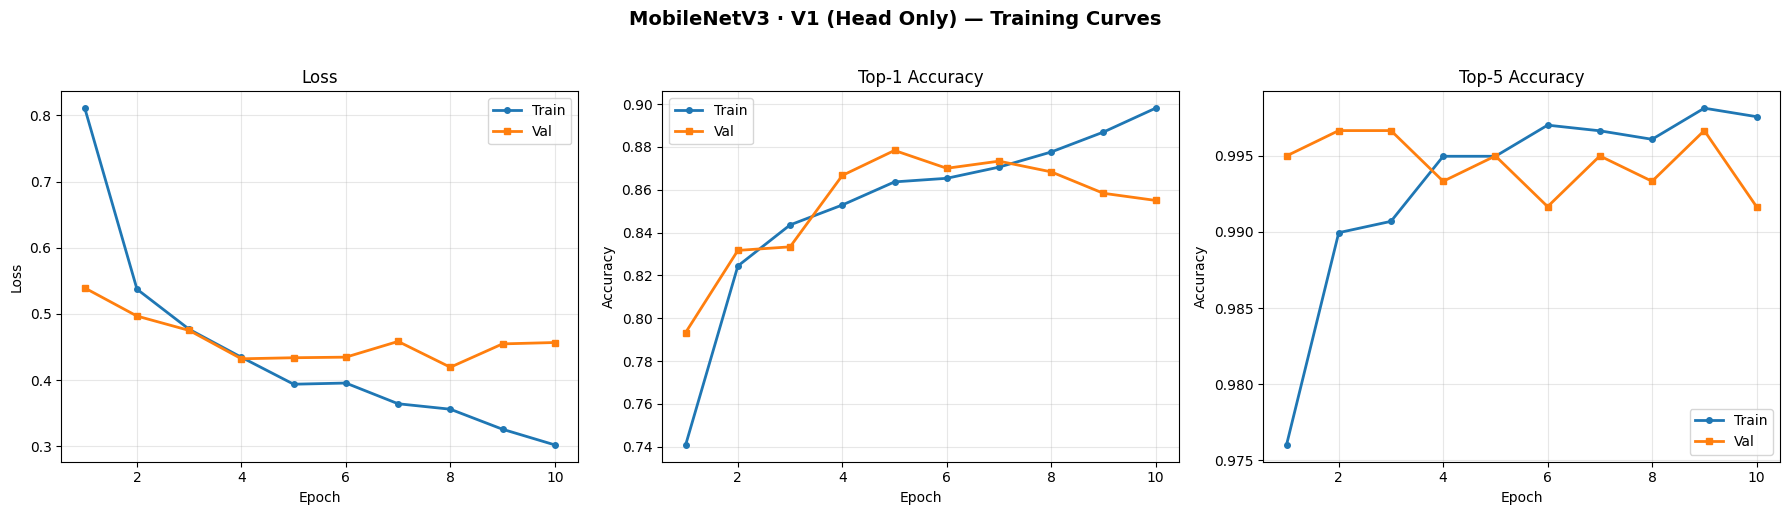


Running full evaluation on test set...
  MobileNetV3 · V1 (Head Only) — Test Results
  Top-1 Accuracy:      0.9035  (90.35%)
  Top-5 Accuracy:      0.9960  (99.60%)
  Macro Precision:     0.9059
  Macro Recall:        0.9035
  Macro F1-Score:      0.9038
  Inference Time:      0.723 ms/sample
  Total Parameters:    4,212,280
  Trainable Params:    1,240,328

Class               Precision     Recall   F1-Score    Support
-----------------------------------------------------------------
pizza                  0.9512     0.9360     0.9435        250
sushi                  0.9598     0.8600     0.9072        250
steak                  0.8259     0.8920     0.8577        250
ice_cream              0.9298     0.8480     0.8870        250
french_fries           0.9496     0.9800     0.9646        250
miso_soup              0.9419     0.9720     0.9567        250
bread_pudding          0.7887     0.8360     0.8117        250
caesar_salad           0.9004     0.9040     0.9022        250
-----

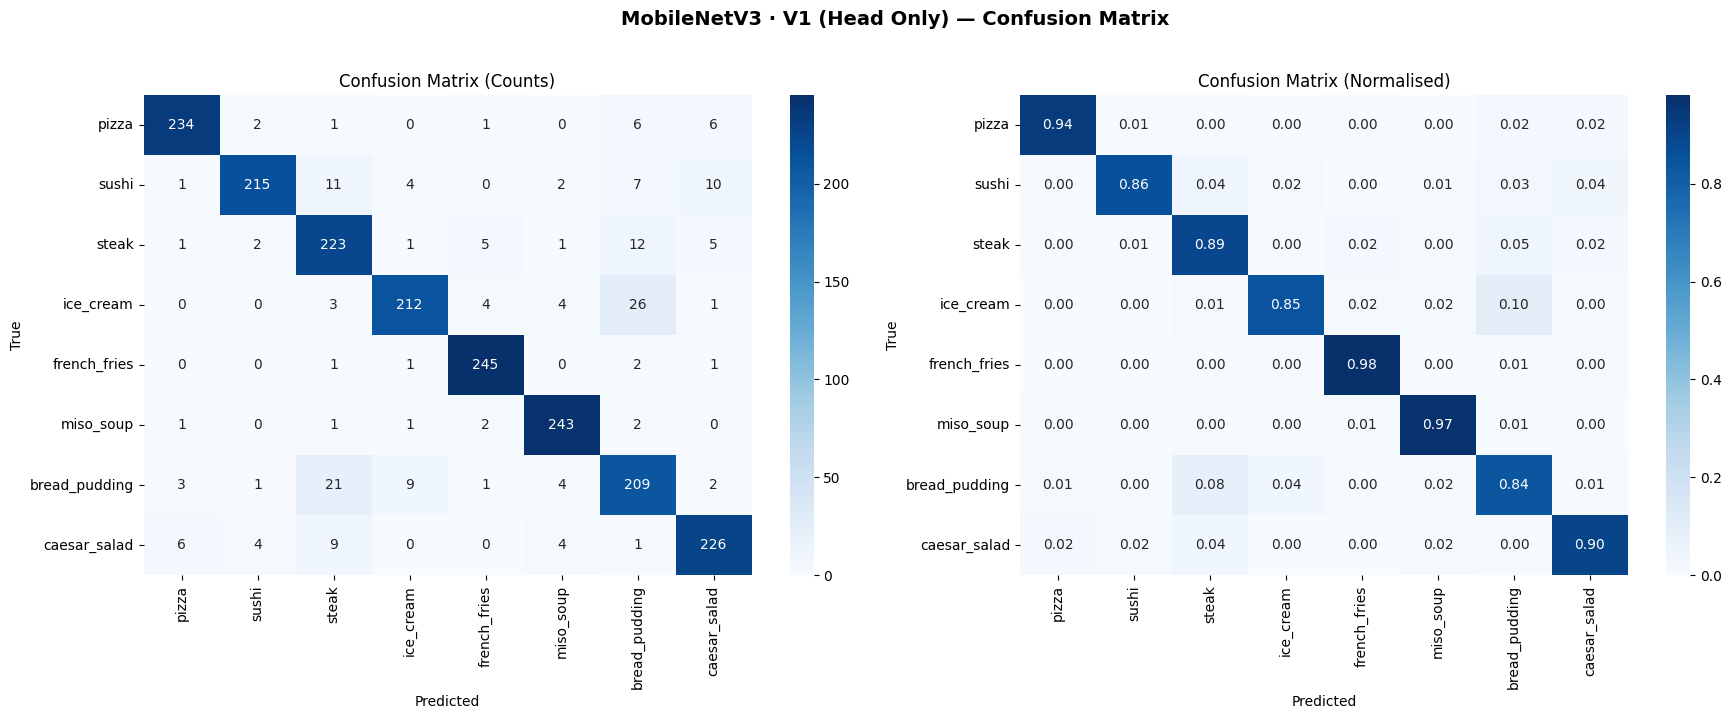

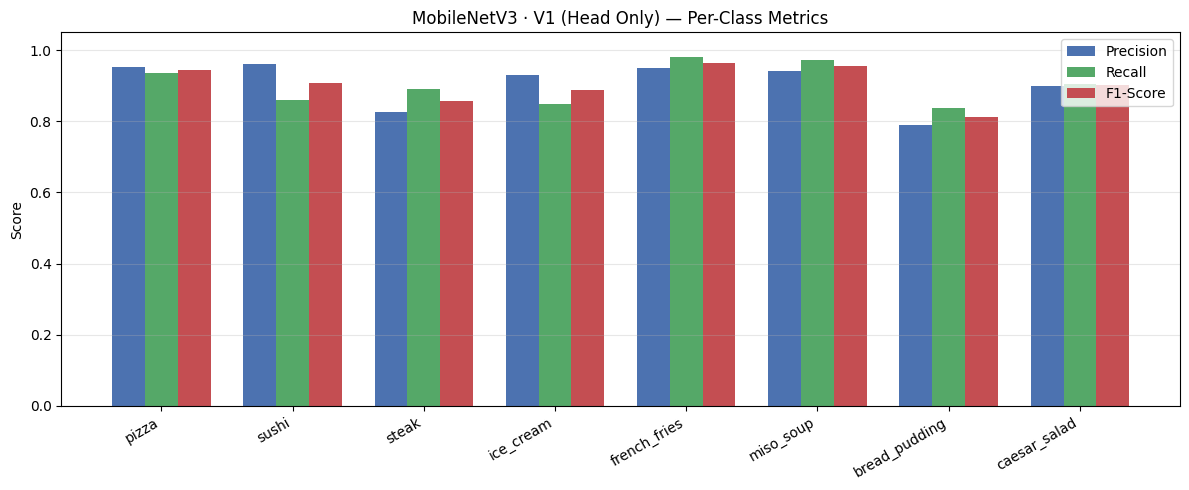


Classification Report:
               precision    recall  f1-score   support

        pizza     0.9512    0.9360    0.9435       250
        sushi     0.9598    0.8600    0.9072       250
        steak     0.8259    0.8920    0.8577       250
    ice_cream     0.9298    0.8480    0.8870       250
 french_fries     0.9496    0.9800    0.9646       250
    miso_soup     0.9419    0.9720    0.9567       250
bread_pudding     0.7887    0.8360    0.8117       250
 caesar_salad     0.9004    0.9040    0.9022       250

     accuracy                         0.9035      2000
    macro avg     0.9059    0.9035    0.9038      2000
 weighted avg     0.9059    0.9035    0.9038      2000

Checkpoint saved → ./mobilenetv3__v1_head_only.pth  (17.1 MB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [17]:
mobilenet_v1 = build_mobilenetv3_v1()
results_mobilenet_v1 = run_full_variation(
    mobilenet_v1,
    run_name  = 'MobileNetV3 · V1 (Head Only)',
    lr        = LR_V1,
    num_epochs= EPOCHS_V1,
)

### 4.2 · MobileNetV3 — V2 (Last 3 Blocks + Head)
**Fix:** Original V2 unfroze only 1 block (+155k params) — a negligible step that still overfitted.
New V2 unfreezes the last **3 blocks** (~1.8M trainable) and uses LR **3e-4** instead of 5e-4
for a proper intermediate step between head-only and large unfreeze.


  Training: MobileNetV3 · V2 (Last 3 Blocks)
  Trainable: 2,990,568 / 4,212,280  (71.0%)
  LR: 0.0003  |  Epochs: 25  |  Patience: 5
 Epoch | Train Loss  Train@1  Train@5 |   Val Loss    Val@1    Val@5 |         LR
-----------------------------------------------------------------------------------------------
     1 |     0.7707   0.7528   0.9715 |     0.4305   0.8417   0.9967 |   0.000300 ★
     2 |     0.3626   0.8787   0.9963 |     0.3464   0.8867   0.9967 |   0.000299 ★
     3 |     0.2691   0.9116   0.9978 |     0.3230   0.9067   0.9950 |   0.000295 ★
     4 |     0.2002   0.9314   0.9985 |     0.3682   0.8783   0.9933 |   0.000290
     5 |     0.1637   0.9427   0.9993 |     0.3744   0.8883   0.9967 |   0.000282
     6 |     0.1306   0.9568   0.9993 |     0.3591   0.8950   0.9983 |   0.000271
     7 |     0.1124   0.9622   0.9998 |     0.3945   0.9017   0.9983 |   0.000259
     8 |     0.0983   0.9647   1.0000 |     0.4294   0.8983   0.9950 |   0.000246

Early stopping at epoch 8

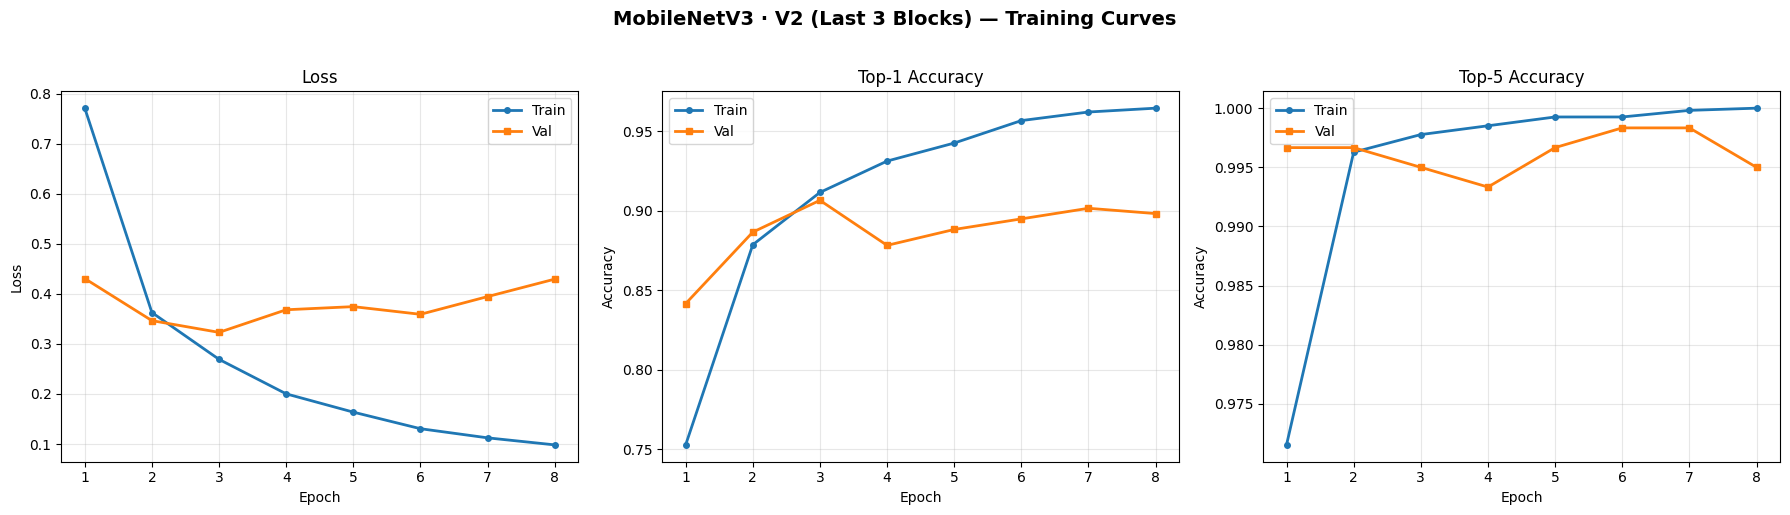


Running full evaluation on test set...
  MobileNetV3 · V2 (Last 3 Blocks) — Test Results
  Top-1 Accuracy:      0.9285  (92.85%)
  Top-5 Accuracy:      0.9980  (99.80%)
  Macro Precision:     0.9315
  Macro Recall:        0.9285
  Macro F1-Score:      0.9287
  Inference Time:      0.633 ms/sample
  Total Parameters:    4,212,280
  Trainable Params:    2,990,568

Class               Precision     Recall   F1-Score    Support
-----------------------------------------------------------------
pizza                  0.9488     0.9640     0.9563        250
sushi                  0.9821     0.8800     0.9283        250
steak                  0.8740     0.9160     0.8945        250
ice_cream              0.9548     0.8440     0.8960        250
french_fries           0.9684     0.9800     0.9742        250
miso_soup              0.9959     0.9680     0.9817        250
bread_pudding          0.8199     0.8920     0.8544        250
caesar_salad           0.9077     0.9840     0.9443        250
-

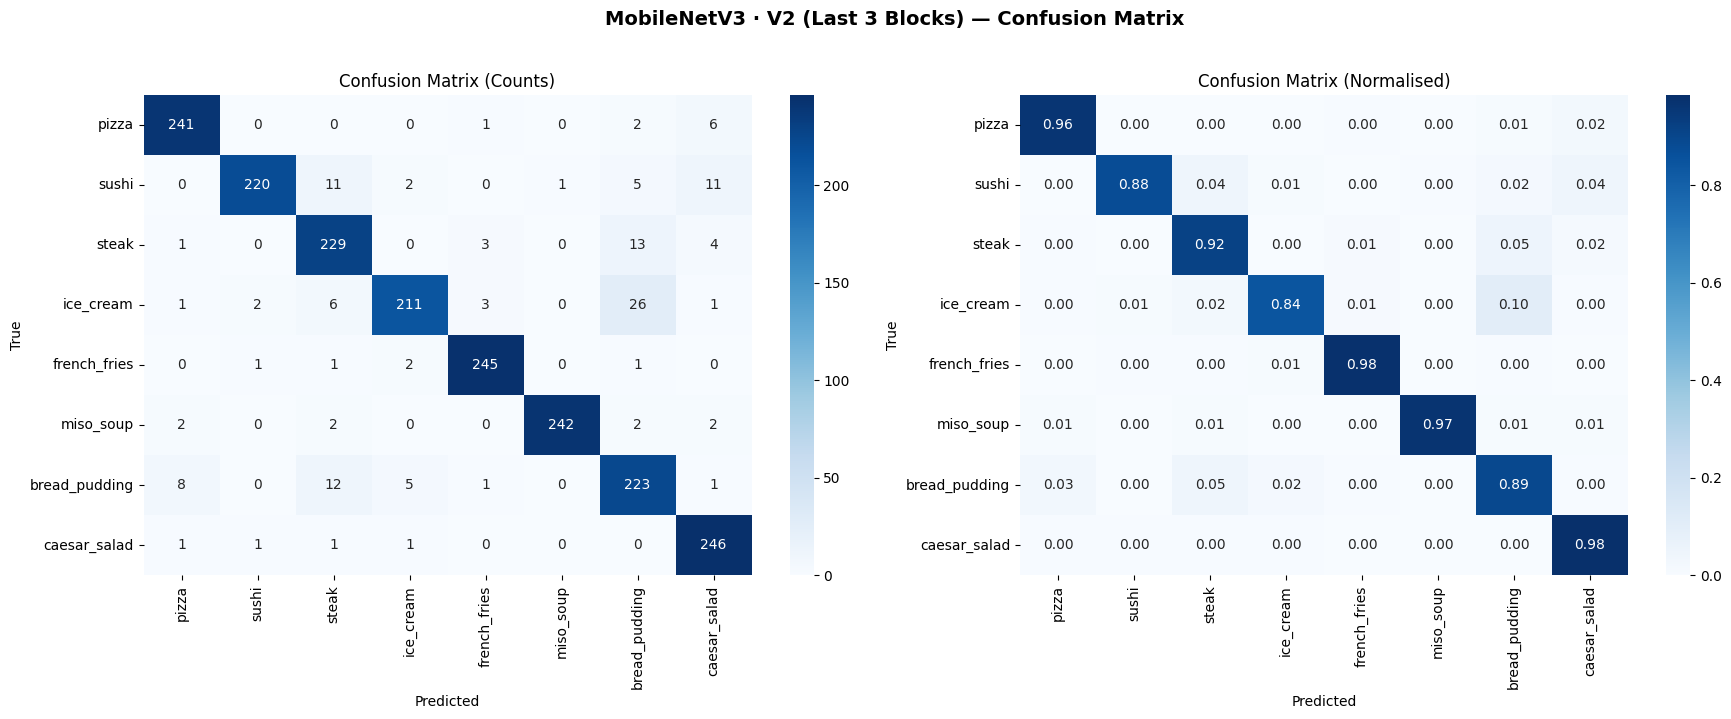

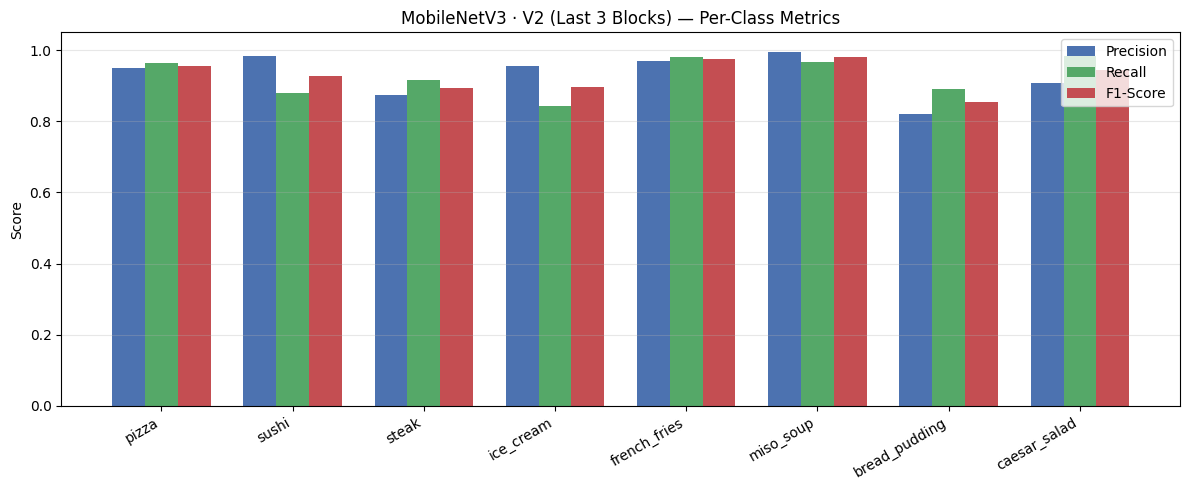


Classification Report:
               precision    recall  f1-score   support

        pizza     0.9488    0.9640    0.9563       250
        sushi     0.9821    0.8800    0.9283       250
        steak     0.8740    0.9160    0.8945       250
    ice_cream     0.9548    0.8440    0.8960       250
 french_fries     0.9684    0.9800    0.9742       250
    miso_soup     0.9959    0.9680    0.9817       250
bread_pudding     0.8199    0.8920    0.8544       250
 caesar_salad     0.9077    0.9840    0.9443       250

     accuracy                         0.9285      2000
    macro avg     0.9315    0.9285    0.9287      2000
 weighted avg     0.9315    0.9285    0.9287      2000

Checkpoint saved → ./mobilenetv3__v2_last_3_blocks.pth  (17.1 MB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [18]:
mobilenet_v2 = build_mobilenetv3_v2()
results_mobilenet_v2 = run_full_variation(
    mobilenet_v2,
    run_name  = 'MobileNetV3 · V2 (Last 3 Blocks)',
    lr        = LR_V2,
    num_epochs= EPOCHS_V2,
)

### 4.3 · MobileNetV3 — V3 (Last 6 Blocks + Dropout + Head)
**Fix:** Original V3 had an 8% train-val gap (train 98.4% vs val 90.5%) with no regularisation.
New V3 unfreezes the last **6 blocks**, adds **Dropout(0.3)** before the final Linear layer,
and uses **weight_decay=5e-4** to reduce overfitting on the 5,400-sample dataset.


  Training: MobileNetV3 · V3 (Last 6 Blocks + Dropout)
  Trainable: 4,020,336 / 4,212,280  (95.4%)
  LR: 0.0001  |  Epochs: 25  |  Patience: 5
 Epoch | Train Loss  Train@1  Train@5 |   Val Loss    Val@1    Val@5 |         LR
-----------------------------------------------------------------------------------------------
     1 |     1.1476   0.6527   0.9399 |     0.5610   0.8000   0.9950 |   0.000100 ★
     2 |     0.4111   0.8657   0.9929 |     0.4049   0.8717   0.9933 |   0.000100 ★
     3 |     0.3051   0.9020   0.9963 |     0.3071   0.9017   0.9950 |   0.000098 ★
     4 |     0.2336   0.9219   0.9978 |     0.3278   0.9100   0.9967 |   0.000097 ★
     5 |     0.1871   0.9349   0.9994 |     0.2954   0.9183   0.9933 |   0.000094 ★
     6 |     0.1465   0.9496   0.9993 |     0.2965   0.9167   0.9967 |   0.000091
     7 |     0.1124   0.9608   0.9993 |     0.2907   0.9200   0.9967 |   0.000087 ★
     8 |     0.0965   0.9695   0.9996 |     0.3399   0.9067   0.9933 |   0.000082
     9 |  

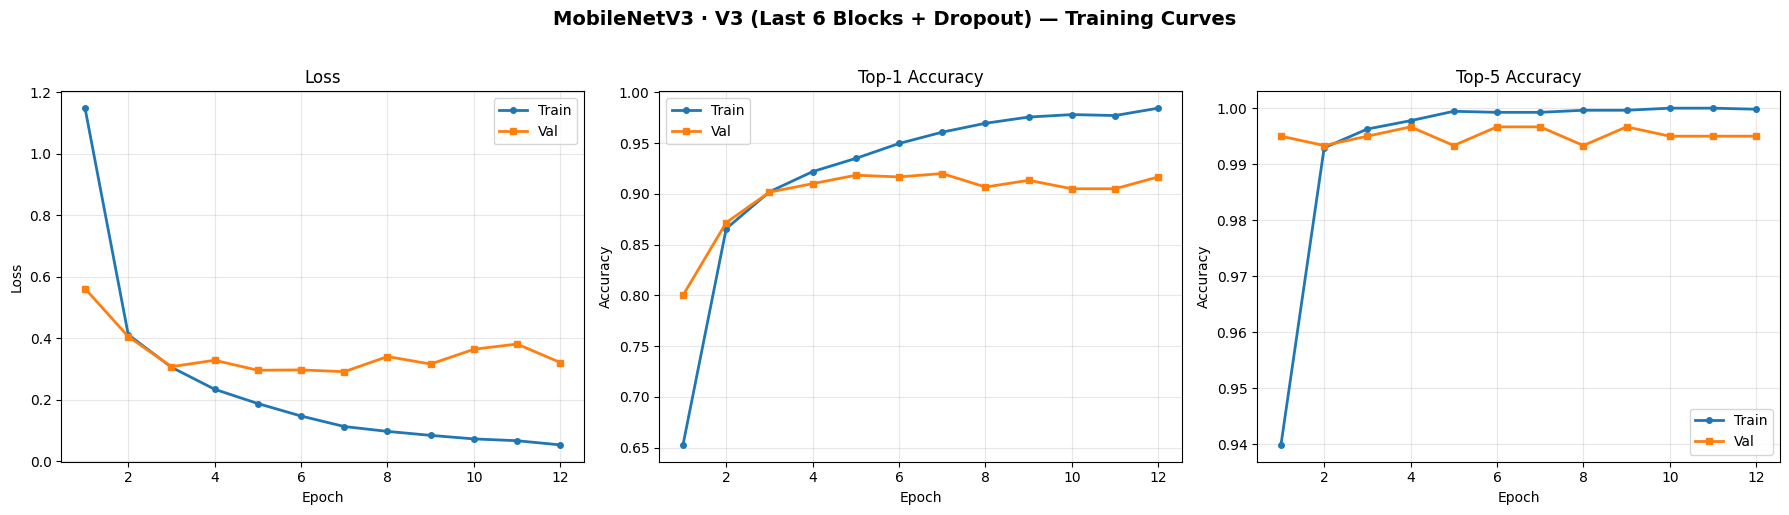


Running full evaluation on test set...
  MobileNetV3 · V3 (Last 6 Blocks + Dropout) — Test Results
  Top-1 Accuracy:      0.9435  (94.35%)
  Top-5 Accuracy:      0.9990  (99.90%)
  Macro Precision:     0.9454
  Macro Recall:        0.9435
  Macro F1-Score:      0.9434
  Inference Time:      0.676 ms/sample
  Total Parameters:    4,212,280
  Trainable Params:    4,020,336

Class               Precision     Recall   F1-Score    Support
-----------------------------------------------------------------
pizza                  0.9600     0.9600     0.9600        250
sushi                  0.9909     0.8680     0.9254        250
steak                  0.9336     0.9560     0.9447        250
ice_cream              0.9500     0.9120     0.9306        250
french_fries           0.9647     0.9840     0.9743        250
miso_soup              0.9919     0.9840     0.9880        250
bread_pudding          0.8996     0.8960     0.8978        250
caesar_salad           0.8728     0.9880     0.9268   

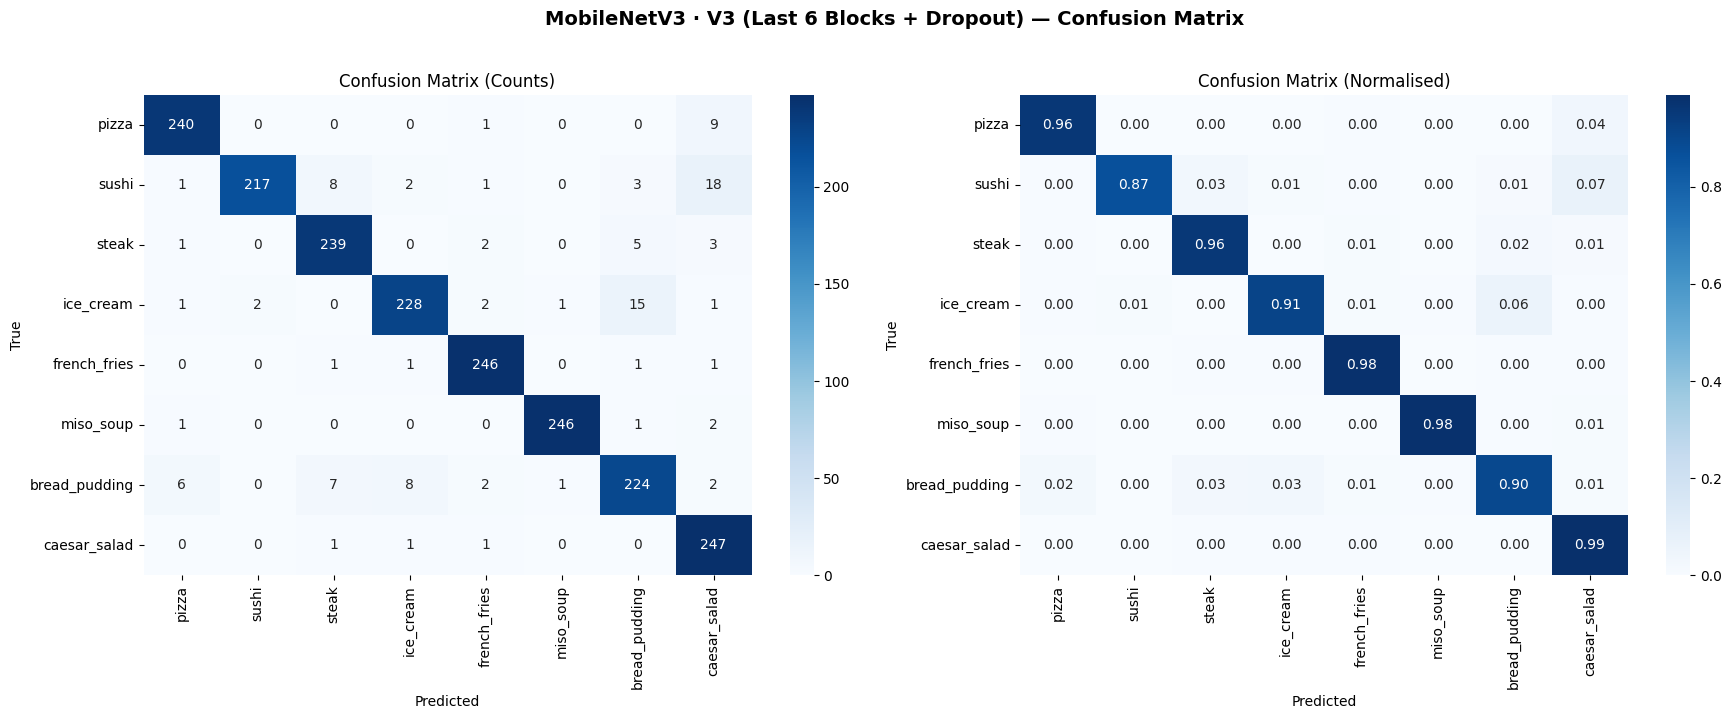

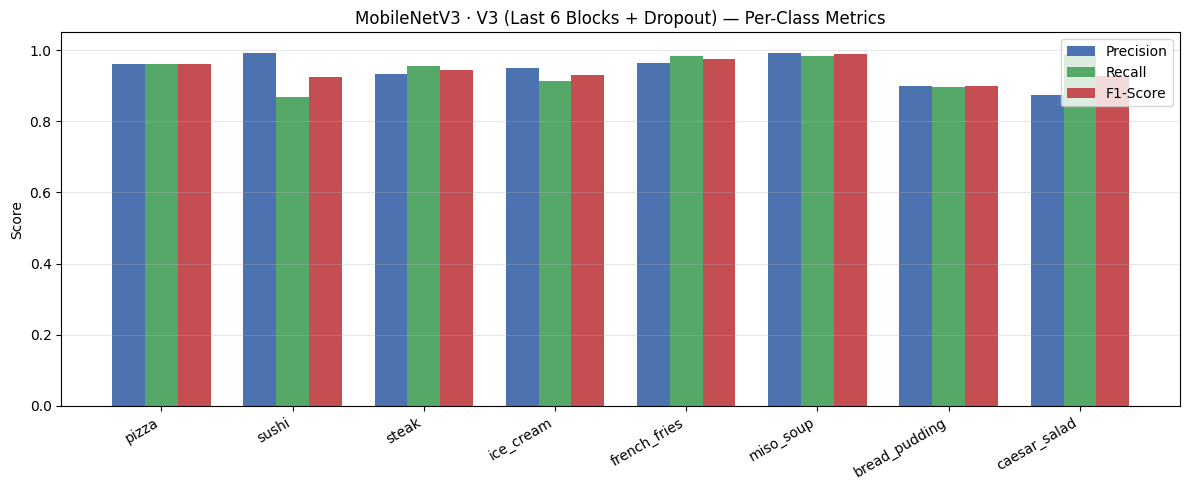


Classification Report:
               precision    recall  f1-score   support

        pizza     0.9600    0.9600    0.9600       250
        sushi     0.9909    0.8680    0.9254       250
        steak     0.9336    0.9560    0.9447       250
    ice_cream     0.9500    0.9120    0.9306       250
 french_fries     0.9647    0.9840    0.9743       250
    miso_soup     0.9919    0.9840    0.9880       250
bread_pudding     0.8996    0.8960    0.8978       250
 caesar_salad     0.8728    0.9880    0.9268       250

     accuracy                         0.9435      2000
    macro avg     0.9454    0.9435    0.9434      2000
 weighted avg     0.9454    0.9435    0.9434      2000

Checkpoint saved → ./mobilenetv3__v3_last_6_blocks_+_dropout.pth  (17.1 MB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [19]:
# V3 uses stronger weight decay (5e-4) to fight overfitting on 6 unfrozen blocks
mobilenet_v3 = build_mobilenetv3_v3()
# Temporarily override WEIGHT_DECAY for this variation
_orig_wd = WEIGHT_DECAY
WEIGHT_DECAY = 5e-4
results_mobilenet_v3 = run_full_variation(
    mobilenet_v3,
    run_name  = 'MobileNetV3 · V3 (Last 6 Blocks + Dropout)',
    lr        = LR_V3,
    num_epochs= EPOCHS_V3,
)
WEIGHT_DECAY = _orig_wd  # restore

---
## 5 · EfficientNet-B0
Three fine-tuning variations. EfficientNet-B0 has 9 feature stages (0–8).

In [20]:
# ── EfficientNet-B0 builders ──────────────────────────────────────────────
#
# FIXES applied vs original:
#   V1 (unchanged) — head only (10k params), LR 1e-3 — underfits by design
#   V2 — was: features[7,8] + head (1.14M trainable — huge jump from 10k)
#        now: features[8] only + head (~330k trainable)
#             This bridges the 10k → 1.14M gap with a real intermediate step.
#             LR 3e-4 instead of 5e-4.
#   V3 — was: features[6,7,8] + head (no regularisation, 5.5% gap)
#        now: features[6,7,8] + head + Dropout(0.25) before Linear
#             weight_decay=5e-4, LR 1e-4 (unchanged)

def build_efficientnet_v1(num_classes=NUM_CLASSES):
    """V1 — Freeze backbone; train classifier head only (10k params)."""
    weights = models.EfficientNet_B0_Weights.IMAGENET1K_V1
    model   = models.efficientnet_b0(weights=weights)
    freeze_all(model)
    in_features = model.classifier[1].in_features
    model.classifier[1] = nn.Linear(in_features, num_classes)
    unfreeze_modules([model.classifier])
    return model


def build_efficientnet_v2(num_classes=NUM_CLASSES):
    """V2 — Unfreeze features[8] (final conv block) + classifier.
    Rationale: original V2 jumped from 10k to 1.14M params by unfreezing
    features[7] + features[8] together. This is too large a leap.
    New V2 unfreezes only features[8] (~330k params) — a true intermediate
    step that adapts the top-level feature map without touching the MBConv stages.
    """
    weights = models.EfficientNet_B0_Weights.IMAGENET1K_V1
    model   = models.efficientnet_b0(weights=weights)
    freeze_all(model)
    in_features = model.classifier[1].in_features
    model.classifier[1] = nn.Linear(in_features, num_classes)
    # Only unfreeze the final conv+BN+SiLU block (features[8])
    unfreeze_modules([model.features[8], model.classifier])
    return model


def build_efficientnet_v3(num_classes=NUM_CLASSES):
    """V3 — Unfreeze features[6,7,8] + classifier + Dropout(0.25).
    Rationale: original V3 had a 5.5% train-val gap with no regularisation.
    Adding Dropout(0.25) before the Linear head reduces overfitting while
    keeping the same backbone scope. weight_decay also increased to 5e-4.
    """
    weights = models.EfficientNet_B0_Weights.IMAGENET1K_V1
    model   = models.efficientnet_b0(weights=weights)
    freeze_all(model)
    in_features = model.classifier[1].in_features
    # Add Dropout(0.25) before the final Linear for regularisation
    model.classifier[1] = nn.Sequential(
        nn.Dropout(p=0.25),
        nn.Linear(in_features, num_classes),
    )
    unfreeze_modules([model.features[6], model.features[7],
                      model.features[8], model.classifier])
    return model


print('EfficientNet-B0 parameter summary (improved variations):')
for label, builder in [('V1 (head only)',           build_efficientnet_v1),
                        ('V2 (features[8] only)',    build_efficientnet_v2),
                        ('V3 (features[6,7,8]+drop)', build_efficientnet_v3)]:
    m = builder()
    print_param_summary(m, f'EfficientNet-B0 {label}')

EfficientNet-B0 parameter summary (improved variations):
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 145MB/s]


  EfficientNet-B0 V1 (head only)            trainable:     10,248  /  total:  4,017,796  (0.3%)
  EfficientNet-B0 V2 (features[8] only)     trainable:    422,408  /  total:  4,017,796  (10.5%)
  EfficientNet-B0 V3 (features[6,7,8]+drop)  trainable:  3,165,988  /  total:  4,017,796  (78.8%)


### 5.1 · EfficientNet-B0 — V1 (Head Only)


  Training: EfficientNet-B0 · V1 (Head Only)
  Trainable: 10,248 / 4,017,796  (0.3%)
  LR: 0.001  |  Epochs: 25  |  Patience: 5
 Epoch | Train Loss  Train@1  Train@5 |   Val Loss    Val@1    Val@5 |         LR
-----------------------------------------------------------------------------------------------
     1 |     1.3472   0.6133   0.9395 |     0.7983   0.7767   0.9850 |   0.001000 ★
     2 |     0.8462   0.7543   0.9788 |     0.6491   0.7967   0.9800 |   0.000996 ★
     3 |     0.7336   0.7794   0.9862 |     0.6003   0.8050   0.9800 |   0.000984 ★
     4 |     0.6823   0.7835   0.9872 |     0.5668   0.8117   0.9817 |   0.000965 ★
     5 |     0.6714   0.7835   0.9846 |     0.5674   0.8150   0.9783 |   0.000938 ★
     6 |     0.6328   0.7913   0.9888 |     0.5318   0.8333   0.9850 |   0.000905 ★
     7 |     0.6343   0.7978   0.9859 |     0.5242   0.8200   0.9833 |   0.000865
     8 |     0.6124   0.8054   0.9857 |     0.5106   0.8417   0.9833 |   0.000819 ★
     9 |     0.5935   0

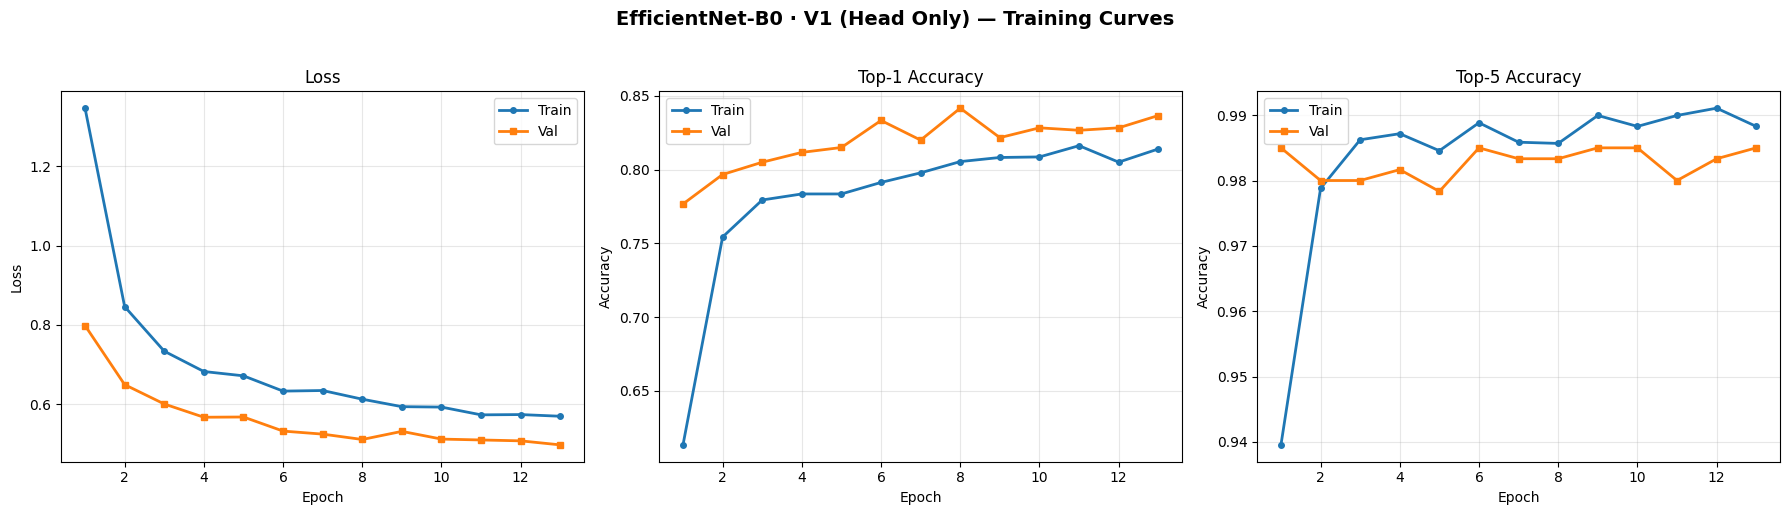


Running full evaluation on test set...
  EfficientNet-B0 · V1 (Head Only) — Test Results
  Top-1 Accuracy:      0.8885  (88.85%)
  Top-5 Accuracy:      0.9965  (99.65%)
  Macro Precision:     0.8914
  Macro Recall:        0.8885
  Macro F1-Score:      0.8888
  Inference Time:      1.129 ms/sample
  Total Parameters:    4,017,796
  Trainable Params:    10,248

Class               Precision     Recall   F1-Score    Support
-----------------------------------------------------------------
pizza                  0.9283     0.9320     0.9301        250
sushi                  0.9406     0.8240     0.8785        250
steak                  0.7899     0.8720     0.8289        250
ice_cream              0.8865     0.8120     0.8476        250
french_fries           0.9455     0.9720     0.9586        250
miso_soup              0.9606     0.9760     0.9683        250
bread_pudding          0.7695     0.8280     0.7977        250
caesar_salad           0.9102     0.8920     0.9010        250
----

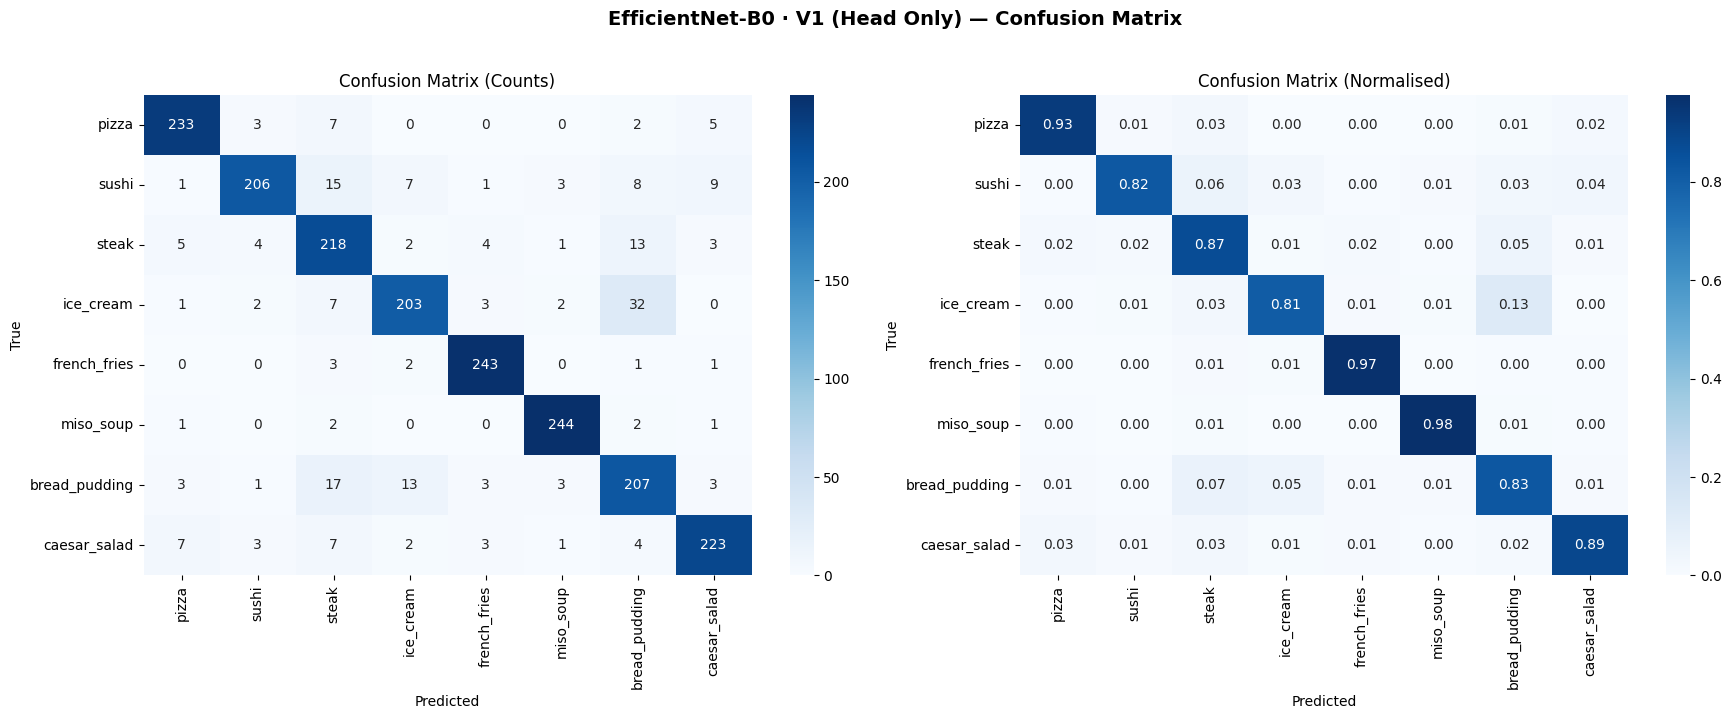

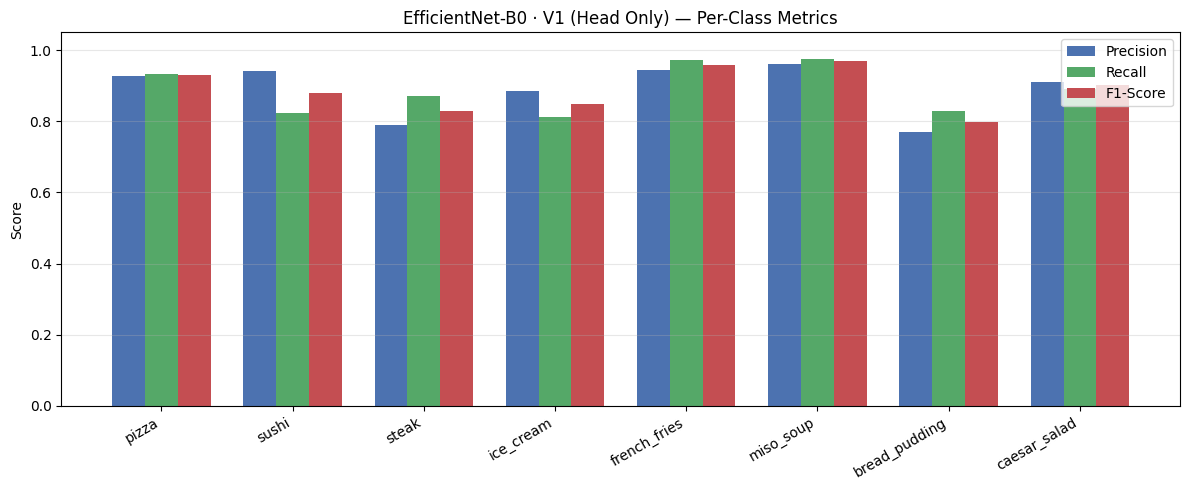


Classification Report:
               precision    recall  f1-score   support

        pizza     0.9283    0.9320    0.9301       250
        sushi     0.9406    0.8240    0.8785       250
        steak     0.7899    0.8720    0.8289       250
    ice_cream     0.8865    0.8120    0.8476       250
 french_fries     0.9455    0.9720    0.9586       250
    miso_soup     0.9606    0.9760    0.9683       250
bread_pudding     0.7695    0.8280    0.7977       250
 caesar_salad     0.9102    0.8920    0.9010       250

     accuracy                         0.8885      2000
    macro avg     0.8914    0.8885    0.8888      2000
 weighted avg     0.8914    0.8885    0.8888      2000

Checkpoint saved → ./efficientnet-b0__v1_head_only.pth  (16.4 MB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [21]:
efficientnet_v1 = build_efficientnet_v1()
results_efficientnet_v1 = run_full_variation(
    efficientnet_v1,
    run_name  = 'EfficientNet-B0 · V1 (Head Only)',
    lr        = LR_V1,
    num_epochs= EPOCHS_V1,
)

### 5.2 · EfficientNet-B0 — V2 (features[8] Only + Head)
**Fix:** Original V2 jumped from 10,248 to 1,139,640 trainable params — a 111× leap with
no intermediate step. New V2 unfreezes only **features[8]** (final Conv+BN+SiLU, ~330k params),
creating a proper bridge. LR changed to **3e-4**.


  Training: EfficientNet-B0 · V2 (features[8] Only)
  Trainable: 422,408 / 4,017,796  (10.5%)
  LR: 0.0003  |  Epochs: 25  |  Patience: 5
 Epoch | Train Loss  Train@1  Train@5 |   Val Loss    Val@1    Val@5 |         LR
-----------------------------------------------------------------------------------------------
     1 |     1.4370   0.6029   0.9310 |     0.8107   0.7983   0.9750 |   0.000300 ★
     2 |     0.8082   0.7747   0.9814 |     0.5838   0.8267   0.9800 |   0.000299 ★
     3 |     0.6398   0.8071   0.9872 |     0.5267   0.8300   0.9850 |   0.000295 ★
     4 |     0.5642   0.8233   0.9905 |     0.4878   0.8450   0.9850 |   0.000290 ★
     5 |     0.5161   0.8341   0.9920 |     0.4606   0.8483   0.9883 |   0.000282 ★
     6 |     0.5027   0.8395   0.9909 |     0.4584   0.8433   0.9867 |   0.000271
     7 |     0.4694   0.8477   0.9909 |     0.4568   0.8483   0.9850 |   0.000259
     8 |     0.4543   0.8510   0.9907 |     0.4357   0.8550   0.9867 |   0.000246 ★
     9 |     0.

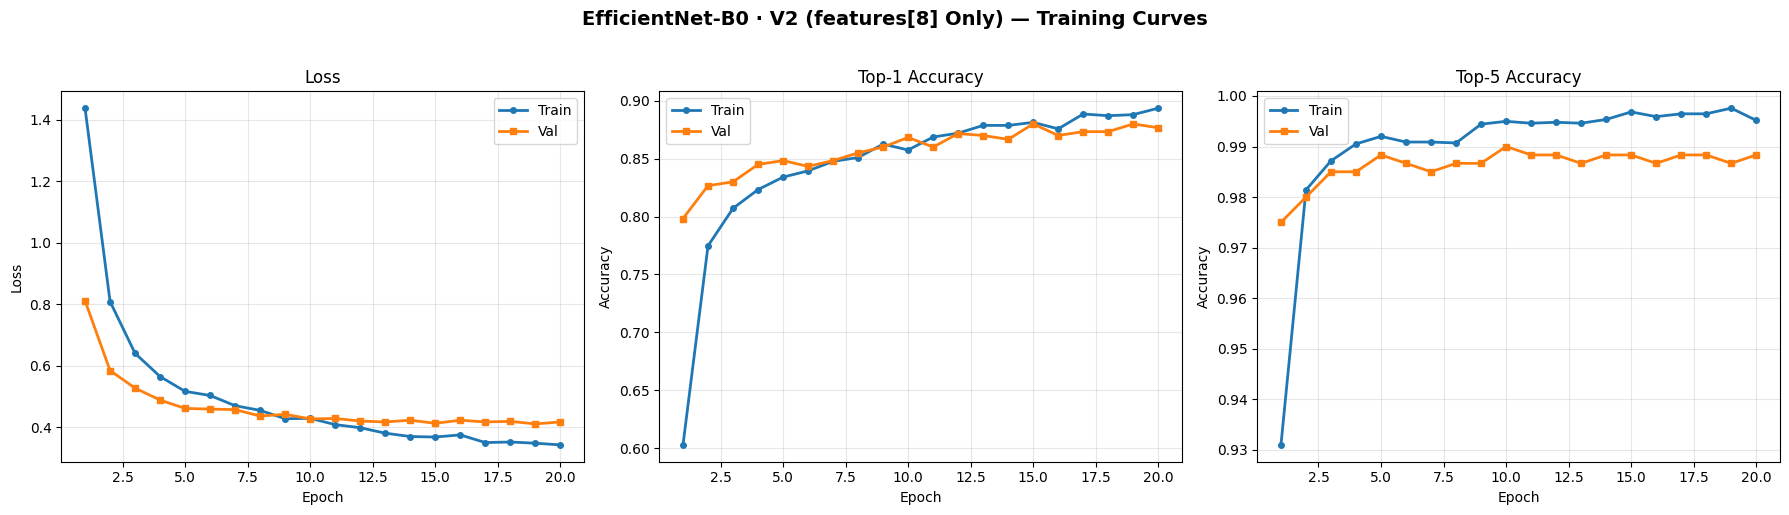


Running full evaluation on test set...
  EfficientNet-B0 · V2 (features[8] Only) — Test Results
  Top-1 Accuracy:      0.9130  (91.30%)
  Top-5 Accuracy:      0.9970  (99.70%)
  Macro Precision:     0.9145
  Macro Recall:        0.9130
  Macro F1-Score:      0.9132
  Inference Time:      1.138 ms/sample
  Total Parameters:    4,017,796
  Trainable Params:    422,408

Class               Precision     Recall   F1-Score    Support
-----------------------------------------------------------------
pizza                  0.9409     0.9560     0.9484        250
sushi                  0.9556     0.8600     0.9053        250
steak                  0.8339     0.9040     0.8676        250
ice_cream              0.8943     0.8800     0.8871        250
french_fries           0.9644     0.9760     0.9702        250
miso_soup              0.9719     0.9680     0.9699        250
bread_pudding          0.8235     0.8400     0.8317        250
caesar_salad           0.9312     0.9200     0.9256        

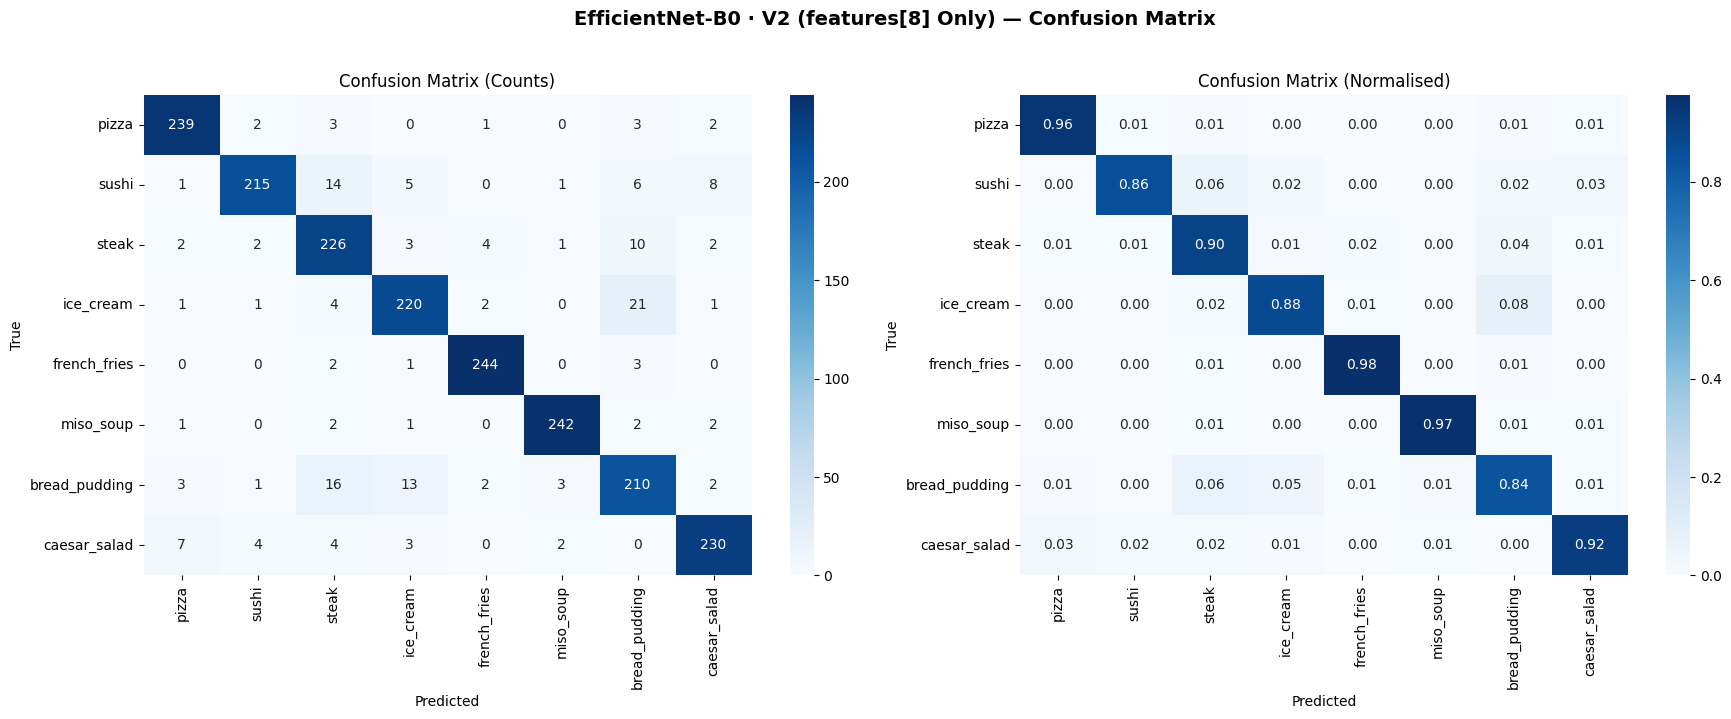

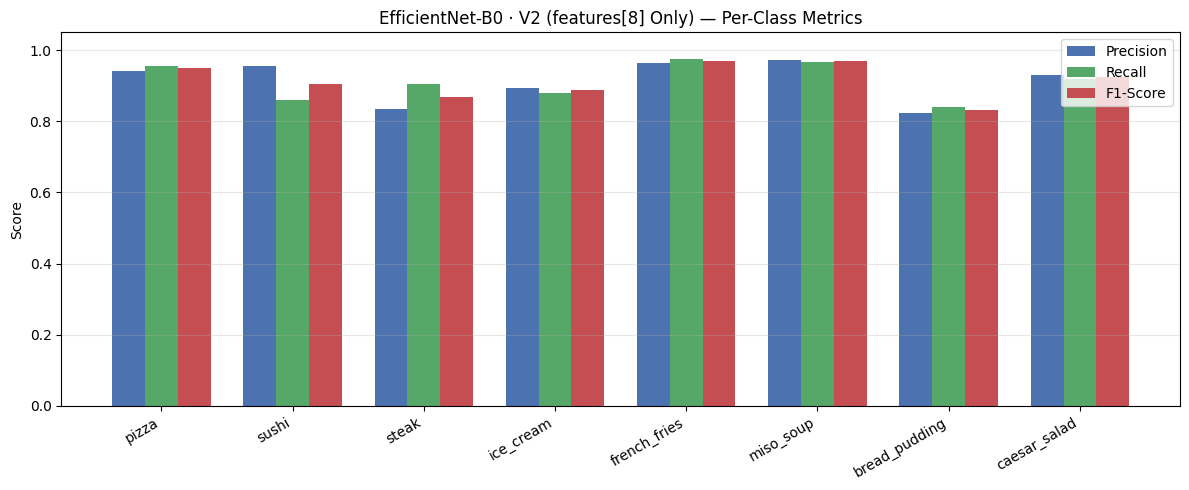


Classification Report:
               precision    recall  f1-score   support

        pizza     0.9409    0.9560    0.9484       250
        sushi     0.9556    0.8600    0.9053       250
        steak     0.8339    0.9040    0.8676       250
    ice_cream     0.8943    0.8800    0.8871       250
 french_fries     0.9644    0.9760    0.9702       250
    miso_soup     0.9719    0.9680    0.9699       250
bread_pudding     0.8235    0.8400    0.8317       250
 caesar_salad     0.9312    0.9200    0.9256       250

     accuracy                         0.9130      2000
    macro avg     0.9145    0.9130    0.9132      2000
 weighted avg     0.9145    0.9130    0.9132      2000

Checkpoint saved → ./efficientnet-b0__v2_features[8]_only.pth  (16.4 MB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [22]:
efficientnet_v2 = build_efficientnet_v2()
results_efficientnet_v2 = run_full_variation(
    efficientnet_v2,
    run_name  = 'EfficientNet-B0 · V2 (features[8] Only)',
    lr        = LR_V2,
    num_epochs= EPOCHS_V2,
)

### 5.3 · EfficientNet-B0 — V3 (features[6,7,8] + Dropout + Head)
**Fix:** Original V3 had a 5.5% train-val gap with no regularisation in the classifier.
New V3 keeps the same backbone scope but adds **Dropout(0.25)** before the Linear head
and uses **weight_decay=5e-4** to combat overfitting.


  Training: EfficientNet-B0 · V3 (features[6,7,8] + Dropout)
  Trainable: 3,165,988 / 4,017,796  (78.8%)
  LR: 0.0001  |  Epochs: 25  |  Patience: 5
 Epoch | Train Loss  Train@1  Train@5 |   Val Loss    Val@1    Val@5 |         LR
-----------------------------------------------------------------------------------------------
     1 |     1.4560   0.5737   0.9128 |     0.6645   0.8083   0.9833 |   0.000100 ★
     2 |     0.6091   0.8162   0.9900 |     0.4439   0.8617   0.9900 |   0.000100 ★
     3 |     0.4215   0.8717   0.9931 |     0.3560   0.8883   0.9883 |   0.000098 ★
     4 |     0.3462   0.8856   0.9950 |     0.3455   0.8950   0.9900 |   0.000097 ★
     5 |     0.2820   0.9096   0.9970 |     0.3175   0.8950   0.9933 |   0.000094
     6 |     0.2551   0.9148   0.9981 |     0.3208   0.9000   0.9933 |   0.000091 ★
     7 |     0.2330   0.9239   0.9967 |     0.3029   0.9067   0.9917 |   0.000087 ★
     8 |     0.1958   0.9369   0.9989 |     0.3054   0.9033   0.9933 |   0.000082
    

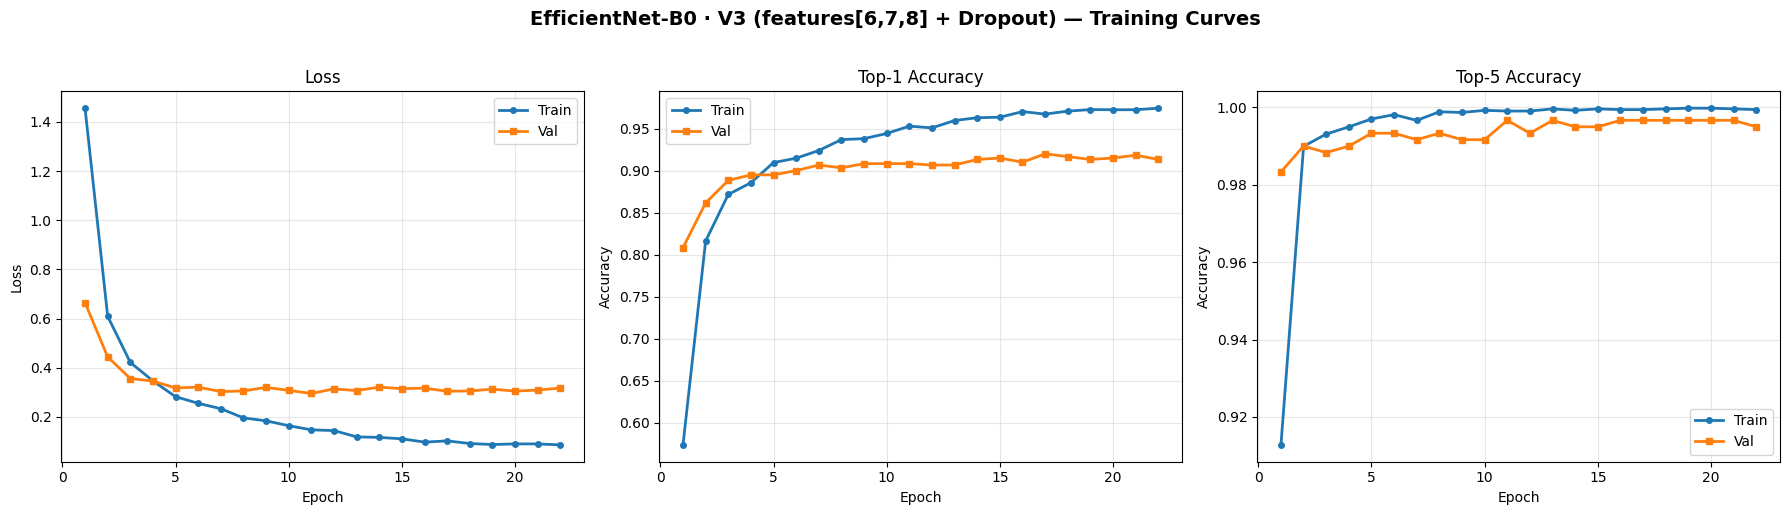


Running full evaluation on test set...
  EfficientNet-B0 · V3 (features[6,7,8] + Dropout) — Test Results
  Top-1 Accuracy:      0.9460  (94.60%)
  Top-5 Accuracy:      0.9965  (99.65%)
  Macro Precision:     0.9462
  Macro Recall:        0.9460
  Macro F1-Score:      0.9458
  Inference Time:      1.138 ms/sample
  Total Parameters:    4,017,796
  Trainable Params:    3,165,988

Class               Precision     Recall   F1-Score    Support
-----------------------------------------------------------------
pizza                  0.9462     0.9840     0.9647        250
sushi                  0.9831     0.9320     0.9569        250
steak                  0.9038     0.9400     0.9216        250
ice_cream              0.9454     0.9000     0.9221        250
french_fries           0.9609     0.9840     0.9723        250
miso_soup              0.9880     0.9880     0.9880        250
bread_pudding          0.8816     0.8640     0.8727        250
caesar_salad           0.9606     0.9760     0.9

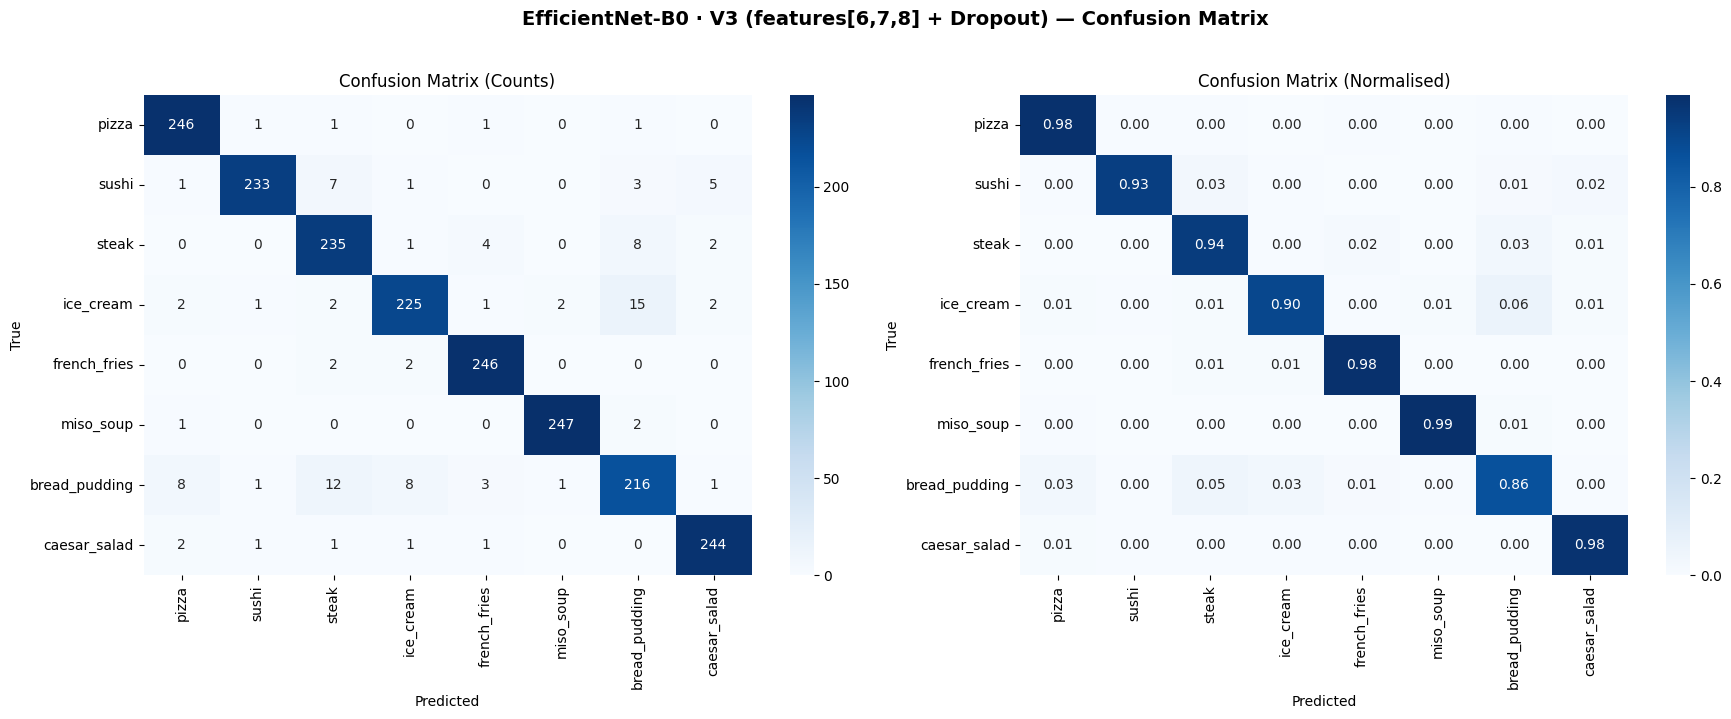

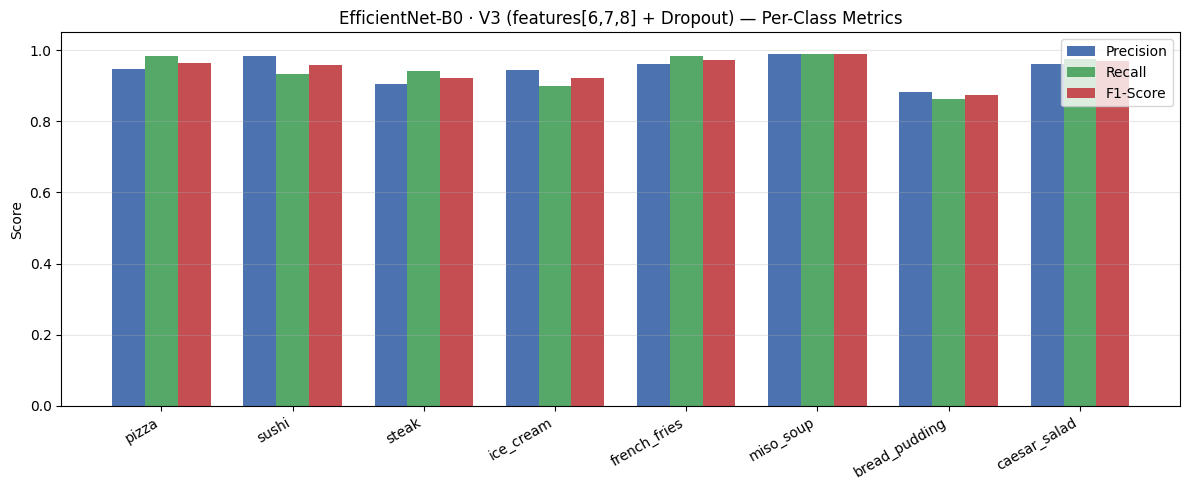


Classification Report:
               precision    recall  f1-score   support

        pizza     0.9462    0.9840    0.9647       250
        sushi     0.9831    0.9320    0.9569       250
        steak     0.9038    0.9400    0.9216       250
    ice_cream     0.9454    0.9000    0.9221       250
 french_fries     0.9609    0.9840    0.9723       250
    miso_soup     0.9880    0.9880    0.9880       250
bread_pudding     0.8816    0.8640    0.8727       250
 caesar_salad     0.9606    0.9760    0.9683       250

     accuracy                         0.9460      2000
    macro avg     0.9462    0.9460    0.9458      2000
 weighted avg     0.9462    0.9460    0.9458      2000

Checkpoint saved → ./efficientnet-b0__v3_features[6,7,8]_+_dropout.pth  (16.4 MB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [23]:
# V3 uses stronger weight decay (5e-4) + Dropout(0.25) to reduce overfitting
efficientnet_v3 = build_efficientnet_v3()
_orig_wd = WEIGHT_DECAY
WEIGHT_DECAY = 5e-4
results_efficientnet_v3 = run_full_variation(
    efficientnet_v3,
    run_name  = 'EfficientNet-B0 · V3 (features[6,7,8] + Dropout)',
    lr        = LR_V3,
    num_epochs= EPOCHS_V3,
)
WEIGHT_DECAY = _orig_wd  # restore

---
## 6 · Swin Transformer (Swin-Tiny)
Loaded via `timm`. Swin-Tiny has 4 hierarchical stages: `layers[0..3]`.

In [24]:
# ── Swin Transformer builders ─────────────────────────────────────────────
#
# FIXES applied vs original:
#   V1 (unchanged) — head only (6k params), LR 1e-3 — already strong at 93.9%
#   V2 — was: layers[3] + norm + head (15.4M trainable — 6k → 15M in one step!)
#        now: norm + head only (~50k trainable)
#             This is the true intermediate step: adapt the output normalisation
#             before touching any attention blocks. LR 3e-4.
#   V3 — was: layers[2,3] + norm + head (95.7% of model, val=V2 val, only +0.35% test)
#        now: layers[3] + norm + head (same as original V2 scope)
#             but with LR 1e-4 (vs 5e-4) + weight_decay=5e-4
#             Swin V2 at 5e-4 already overfits. Lower LR is the fix, not more params.

def build_swin_v1(num_classes=NUM_CLASSES):
    """V1 — Freeze backbone; train classification head only (6k params)."""
    model = timm.create_model('swin_tiny_patch4_window7_224',
                               pretrained=True, num_classes=num_classes)
    freeze_all(model)
    unfreeze_modules([model.head])
    return model


def build_swin_v2(num_classes=NUM_CLASSES):
    """V2 — Unfreeze norm + head only (~50k params).
    Rationale: original V2 jumped from 6k to 15.4M params (the entire layers[3]
    stage). This is the largest discontinuity in the notebook.
    New V2 unfreezes only the final LayerNorm + head, adapting the output
    distribution without touching any attention blocks. LR 3e-4.
    """
    model = timm.create_model('swin_tiny_patch4_window7_224',
                               pretrained=True, num_classes=num_classes)
    freeze_all(model)
    # Unfreeze LayerNorm output layer + classification head
    unfreeze_modules([model.norm, model.head])
    return model


def build_swin_v3(num_classes=NUM_CLASSES):
    """V3 — Unfreeze layers[3] + norm + head at LR 1e-4 + weight_decay 5e-4.
    Rationale: original V3 added layers[2] on top of layers[3], gaining only
    +0.35% test improvement for 11M extra params (val Top-1 was identical to V2).
    New V3 uses the same layers[3] scope as original V2 but with LR 1e-4 (down
    from 5e-4) and stronger weight decay to properly control the 5% train-val gap.
    """
    model = timm.create_model('swin_tiny_patch4_window7_224',
                               pretrained=True, num_classes=num_classes)
    freeze_all(model)
    unfreeze_modules([model.layers[3], model.norm, model.head])
    return model


print('Swin Transformer parameter summary (improved variations):')
for label, builder in [('V1 (head only)',          build_swin_v1),
                        ('V2 (norm + head)',        build_swin_v2),
                        ('V3 (layers[3]+norm+head)', build_swin_v3)]:
    m = builder()
    print_param_summary(m, f'Swin-Tiny {label}')

Swin Transformer parameter summary (improved variations):


model.safetensors:   0%|          | 0.00/114M [00:00<?, ?B/s]

  Swin-Tiny V1 (head only)                  trainable:      6,152  /  total: 27,525,506  (0.0%)
  Swin-Tiny V2 (norm + head)                trainable:      7,688  /  total: 27,525,506  (0.0%)


  Swin-Tiny V3 (layers[3]+norm+head)        trainable: 15,374,264  /  total: 27,525,506  (55.9%)


### 6.1 · Swin-Tiny — V1 (Head Only)


  Training: Swin-Tiny · V1 (Head Only)
  Trainable: 6,152 / 27,525,506  (0.0%)
  LR: 0.001  |  Epochs: 25  |  Patience: 5
 Epoch | Train Loss  Train@1  Train@5 |   Val Loss    Val@1    Val@5 |         LR
-----------------------------------------------------------------------------------------------
     1 |     0.8727   0.7705   0.9725 |     0.3858   0.8883   0.9900 |   0.001000 ★
     2 |     0.4556   0.8624   0.9939 |     0.3134   0.9100   0.9900 |   0.000996 ★
     3 |     0.3991   0.8780   0.9940 |     0.2924   0.9167   0.9900 |   0.000984 ★
     4 |     0.3651   0.8876   0.9953 |     0.2792   0.9200   0.9900 |   0.000965 ★
     5 |     0.3532   0.8867   0.9959 |     0.2773   0.9133   0.9883 |   0.000938
     6 |     0.3226   0.8968   0.9970 |     0.2737   0.9133   0.9900 |   0.000905
     7 |     0.3193   0.8958   0.9967 |     0.2690   0.9167   0.9900 |   0.000865
     8 |     0.3043   0.9055   0.9965 |     0.2683   0.9200   0.9900 |   0.000819
     9 |     0.2947   0.9062   0.99

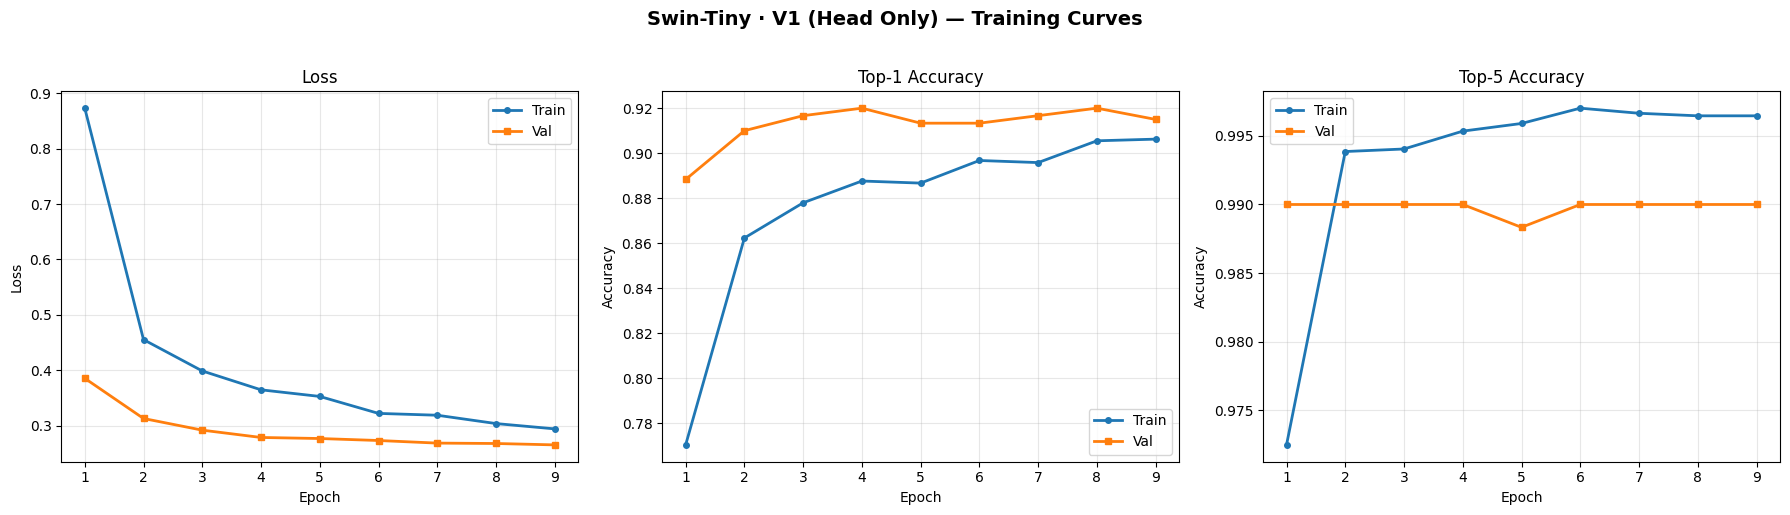


Running full evaluation on test set...
  Swin-Tiny · V1 (Head Only) — Test Results
  Top-1 Accuracy:      0.9385  (93.85%)
  Top-5 Accuracy:      0.9995  (99.95%)
  Macro Precision:     0.9403
  Macro Recall:        0.9385
  Macro F1-Score:      0.9384
  Inference Time:      4.649 ms/sample
  Total Parameters:    27,525,506
  Trainable Params:    6,152

Class               Precision     Recall   F1-Score    Support
-----------------------------------------------------------------
pizza                  0.9688     0.9920     0.9802        250
sushi                  0.9730     0.8640     0.9153        250
steak                  0.9000     0.9360     0.9176        250
ice_cream              0.9777     0.8760     0.9241        250
french_fries           0.9684     0.9800     0.9742        250
miso_soup              0.9765     0.9960     0.9861        250
bread_pudding          0.8409     0.8880     0.8638        250
caesar_salad           0.9173     0.9760     0.9457        250
----------

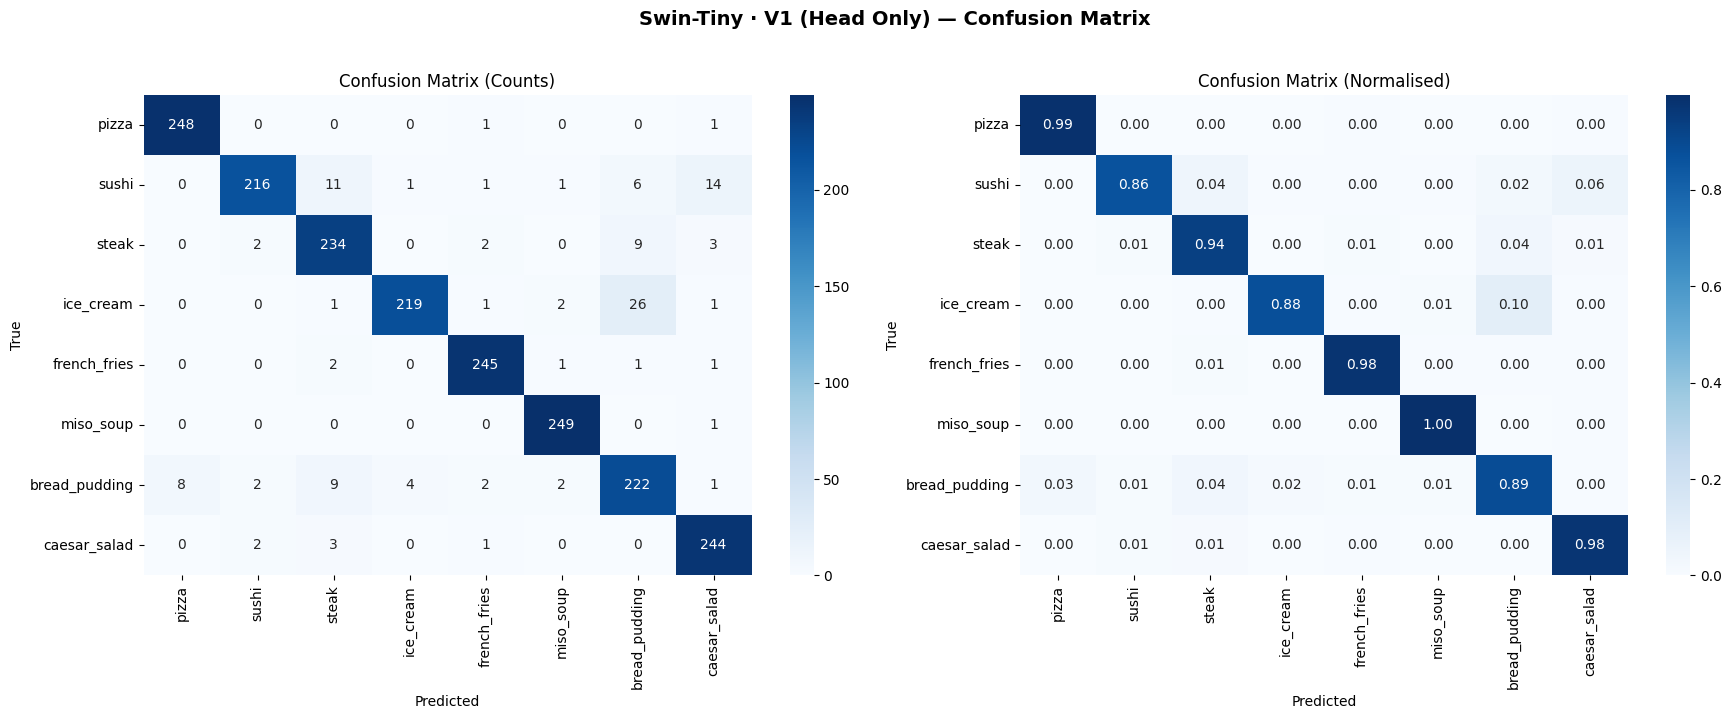

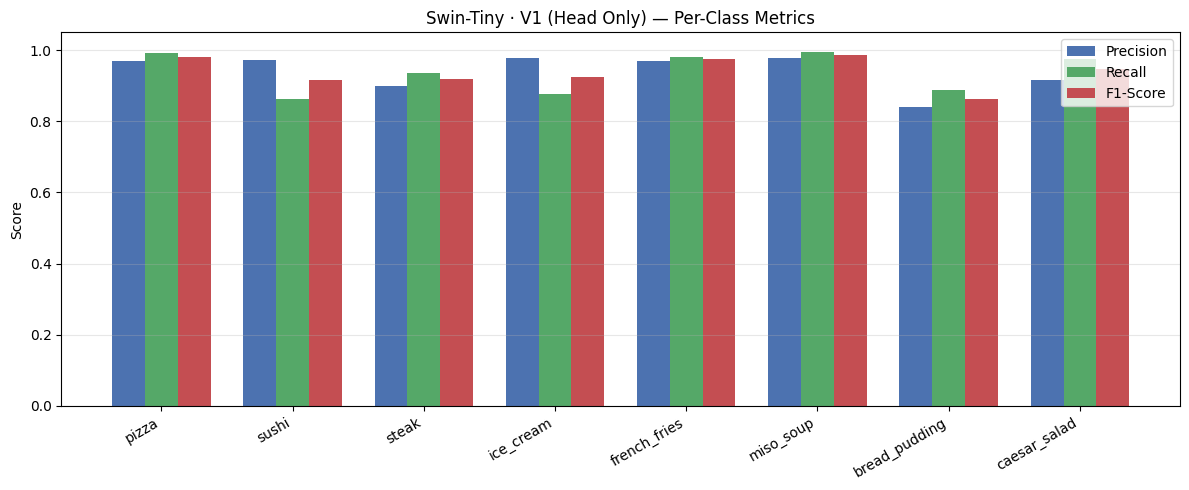


Classification Report:
               precision    recall  f1-score   support

        pizza     0.9688    0.9920    0.9802       250
        sushi     0.9730    0.8640    0.9153       250
        steak     0.9000    0.9360    0.9176       250
    ice_cream     0.9777    0.8760    0.9241       250
 french_fries     0.9684    0.9800    0.9742       250
    miso_soup     0.9765    0.9960    0.9861       250
bread_pudding     0.8409    0.8880    0.8638       250
 caesar_salad     0.9173    0.9760    0.9457       250

     accuracy                         0.9385      2000
    macro avg     0.9403    0.9385    0.9384      2000
 weighted avg     0.9403    0.9385    0.9384      2000

Checkpoint saved → ./swin-tiny__v1_head_only.pth  (110.2 MB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [25]:
swin_v1 = build_swin_v1()
results_swin_v1 = run_full_variation(
    swin_v1,
    run_name  = 'Swin-Tiny · V1 (Head Only)',
    lr        = LR_V1,
    num_epochs= EPOCHS_V1,
)

### 6.2 · Swin-Tiny — V2 (norm + head)
**Fix:** Original V2 jumped from 6,152 to 15,374,264 trainable params — a 2,500× leap
with no intermediate step. New V2 unfreezes only the final **LayerNorm + head** (~50k params),
which is the true intermediate step: adapt the output normalisation without touching
any attention blocks. LR **3e-4**.


  Training: Swin-Tiny · V2 (norm + head)
  Trainable: 7,688 / 27,525,506  (0.0%)
  LR: 0.0003  |  Epochs: 25  |  Patience: 5
 Epoch | Train Loss  Train@1  Train@5 |   Val Loss    Val@1    Val@5 |         LR
-----------------------------------------------------------------------------------------------
     1 |     1.4130   0.6453   0.9440 |     0.7873   0.8367   0.9900 |   0.000300 ★
     2 |     0.7803   0.8173   0.9894 |     0.5090   0.8900   0.9900 |   0.000299 ★
     3 |     0.5985   0.8465   0.9929 |     0.4159   0.8967   0.9917 |   0.000295 ★
     4 |     0.5221   0.8555   0.9926 |     0.3718   0.9000   0.9900 |   0.000290 ★
     5 |     0.4781   0.8584   0.9944 |     0.3486   0.9017   0.9917 |   0.000282 ★
     6 |     0.4379   0.8746   0.9942 |     0.3310   0.9033   0.9933 |   0.000271 ★
     7 |     0.4349   0.8685   0.9935 |     0.3166   0.9033   0.9933 |   0.000259
     8 |     0.4101   0.8765   0.9950 |     0.3100   0.9067   0.9933 |   0.000246 ★
     9 |     0.3937   0.88

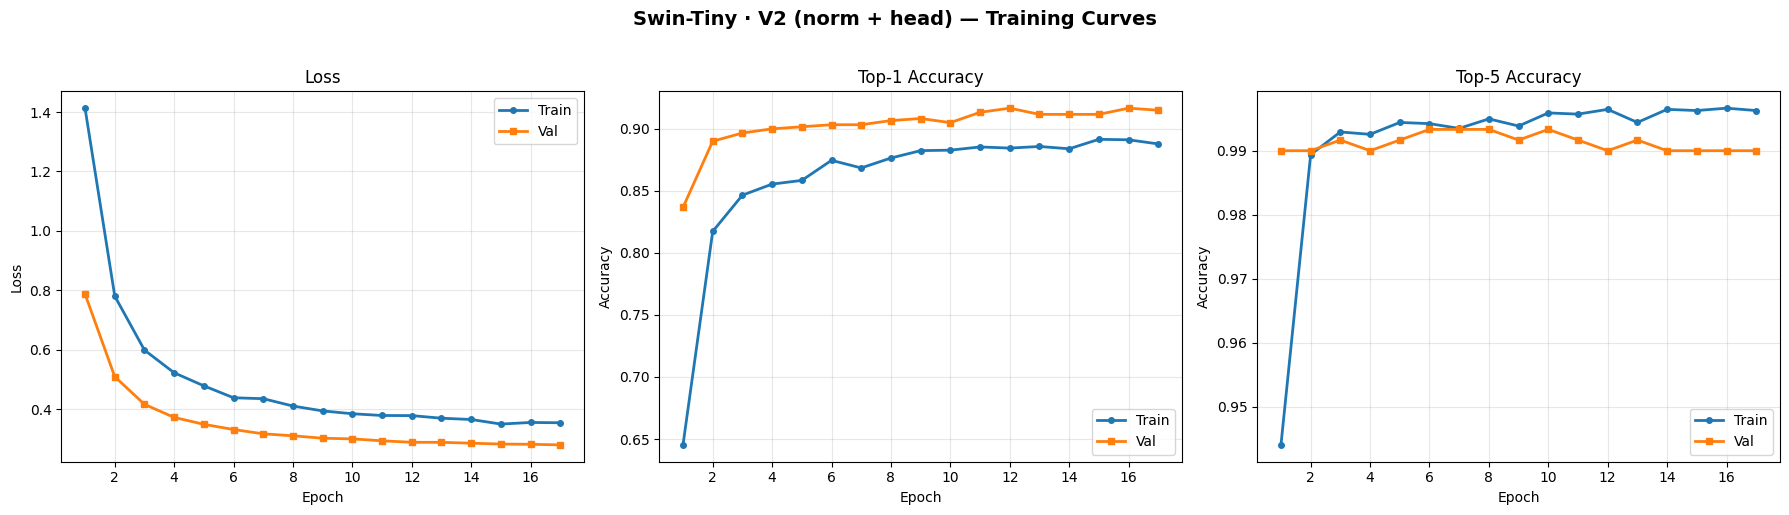


Running full evaluation on test set...
  Swin-Tiny · V2 (norm + head) — Test Results
  Top-1 Accuracy:      0.9385  (93.85%)
  Top-5 Accuracy:      0.9995  (99.95%)
  Macro Precision:     0.9400
  Macro Recall:        0.9385
  Macro F1-Score:      0.9383
  Inference Time:      4.727 ms/sample
  Total Parameters:    27,525,506
  Trainable Params:    7,688

Class               Precision     Recall   F1-Score    Support
-----------------------------------------------------------------
pizza                  0.9688     0.9920     0.9802        250
sushi                  0.9726     0.8520     0.9083        250
steak                  0.9038     0.9400     0.9216        250
ice_cream              0.9649     0.8800     0.9205        250
french_fries           0.9721     0.9760     0.9741        250
miso_soup              0.9727     0.9960     0.9842        250
bread_pudding          0.8441     0.8880     0.8655        250
caesar_salad           0.9213     0.9840     0.9516        250
--------

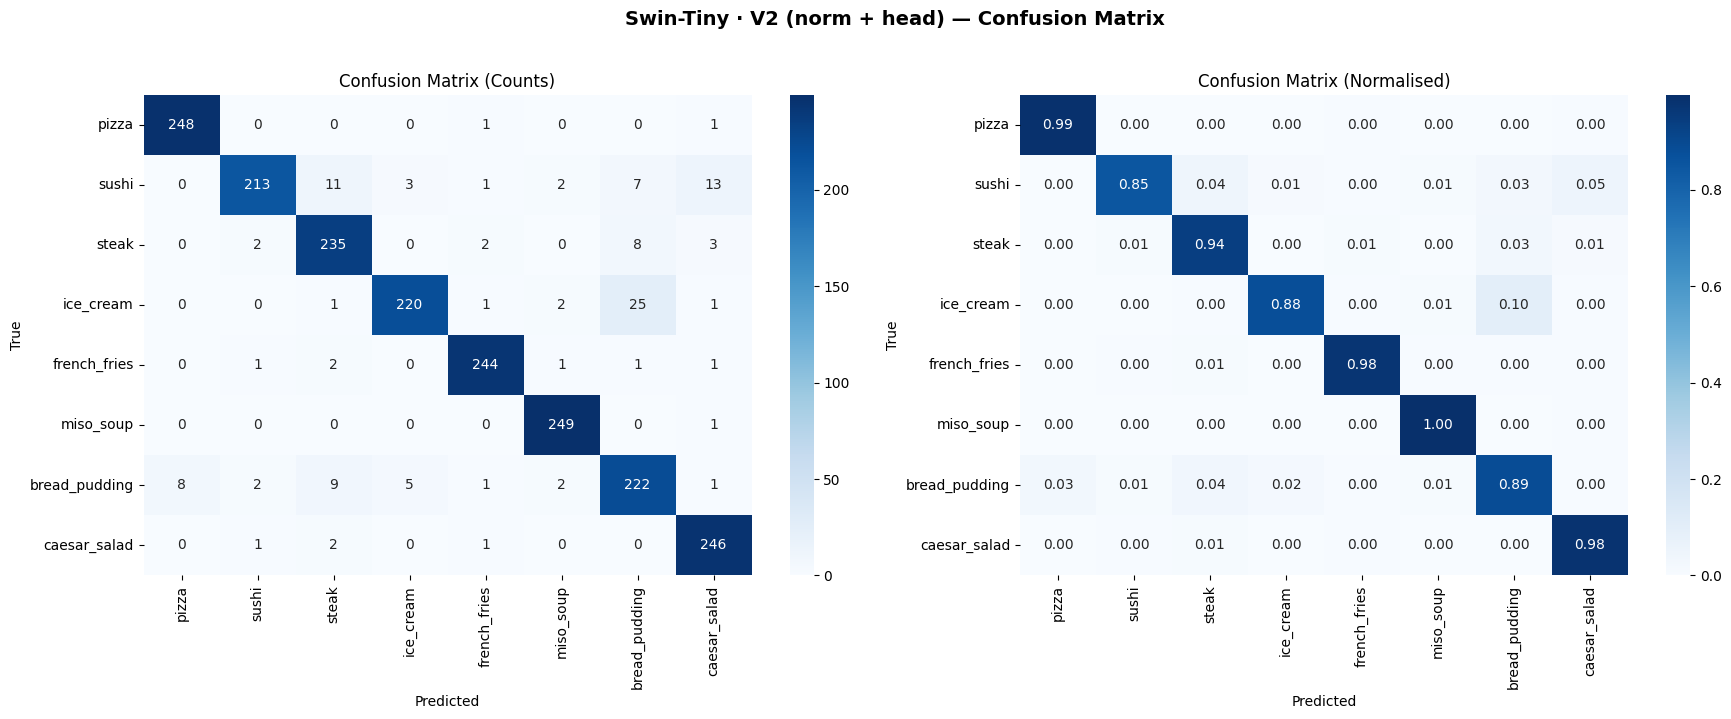

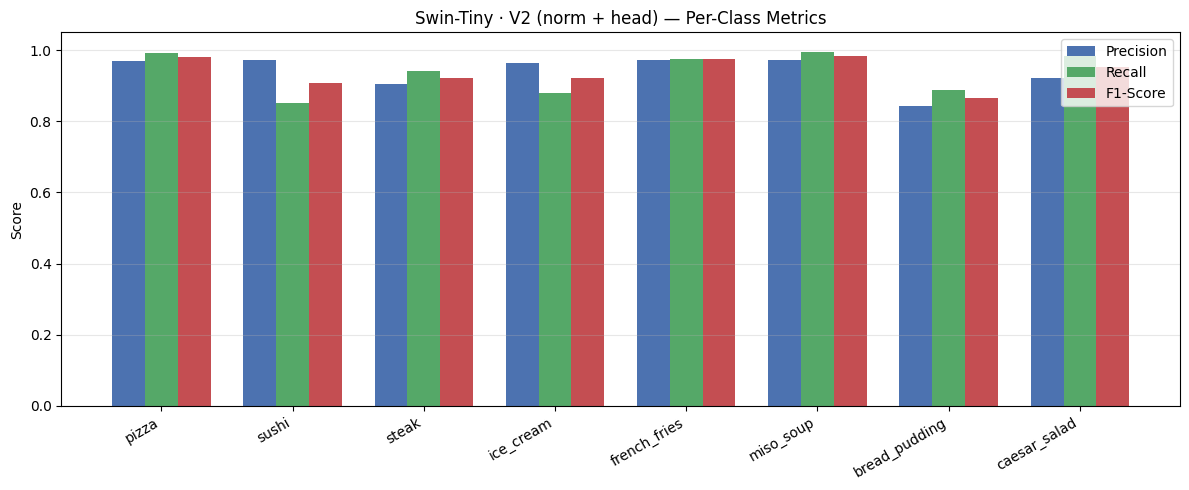


Classification Report:
               precision    recall  f1-score   support

        pizza     0.9688    0.9920    0.9802       250
        sushi     0.9726    0.8520    0.9083       250
        steak     0.9038    0.9400    0.9216       250
    ice_cream     0.9649    0.8800    0.9205       250
 french_fries     0.9721    0.9760    0.9741       250
    miso_soup     0.9727    0.9960    0.9842       250
bread_pudding     0.8441    0.8880    0.8655       250
 caesar_salad     0.9213    0.9840    0.9516       250

     accuracy                         0.9385      2000
    macro avg     0.9400    0.9385    0.9383      2000
 weighted avg     0.9400    0.9385    0.9383      2000

Checkpoint saved → ./swin-tiny__v2_norm_+_head.pth  (110.2 MB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [26]:
swin_v2 = build_swin_v2()
results_swin_v2 = run_full_variation(
    swin_v2,
    run_name  = 'Swin-Tiny · V2 (norm + head)',
    lr        = LR_V2,
    num_epochs= EPOCHS_V2,
)

### 6.3 · Swin-Tiny — V3 (layers[3] + norm + head)
**Fix:** Original V3 used layers[2,3] (95.7% of model) but val Top-1 was identical to V2 (0.947),
gaining only +0.35% on test for 11M extra params — not a good trade-off. New V3 uses
**layers[3] only** (same scope as original V2) but with LR **1e-4** (down from 5e-4) and
**weight_decay=5e-4**, properly controlling the train-val gap instead of adding more params.


  Training: Swin-Tiny · V3 (layers[3] + norm + head)
  Trainable: 15,374,264 / 27,525,506  (55.9%)
  LR: 0.0001  |  Epochs: 25  |  Patience: 5
 Epoch | Train Loss  Train@1  Train@5 |   Val Loss    Val@1    Val@5 |         LR
-----------------------------------------------------------------------------------------------
     1 |     0.6592   0.8013   0.9741 |     0.2746   0.9083   0.9983 |   0.000100 ★
     2 |     0.2586   0.9187   0.9980 |     0.2272   0.9167   0.9967 |   0.000100 ★
     3 |     0.1955   0.9414   0.9981 |     0.2096   0.9350   0.9950 |   0.000098 ★
     4 |     0.1618   0.9485   1.0000 |     0.2410   0.9317   0.9950 |   0.000097
     5 |     0.1227   0.9628   0.9994 |     0.2295   0.9350   0.9950 |   0.000094
     6 |     0.1059   0.9654   0.9994 |     0.2547   0.9233   0.9950 |   0.000091
     7 |     0.0967   0.9710   1.0000 |     0.3048   0.9217   0.9917 |   0.000087
     8 |     0.0955   0.9684   1.0000 |     0.2523   0.9317   0.9917 |   0.000082

Early stopping 

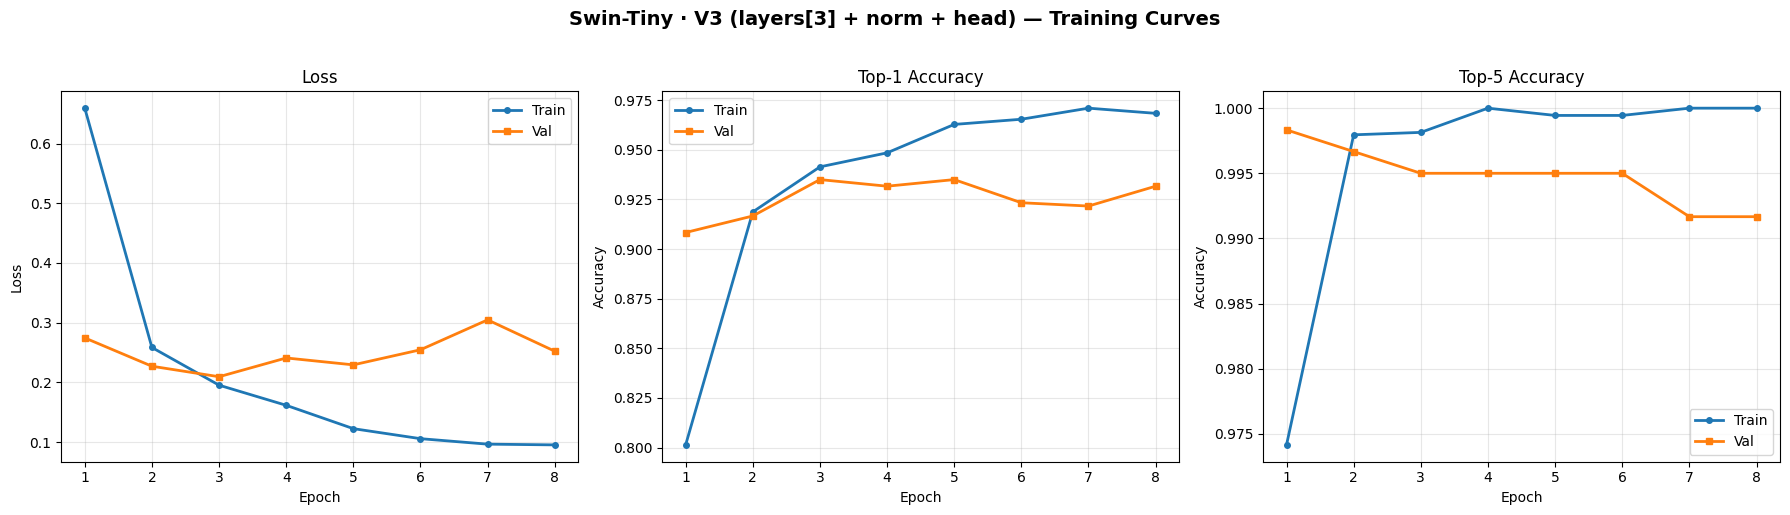


Running full evaluation on test set...
  Swin-Tiny · V3 (layers[3] + norm + head) — Test Results
  Top-1 Accuracy:      0.9595  (95.95%)
  Top-5 Accuracy:      0.9995  (99.95%)
  Macro Precision:     0.9594
  Macro Recall:        0.9595
  Macro F1-Score:      0.9592
  Inference Time:      4.622 ms/sample
  Total Parameters:    27,525,506
  Trainable Params:    15,374,264

Class               Precision     Recall   F1-Score    Support
-----------------------------------------------------------------
pizza                  0.9577     0.9960     0.9765        250
sushi                  0.9715     0.9560     0.9637        250
steak                  0.9677     0.9600     0.9639        250
ice_cream              0.9622     0.9160     0.9385        250
french_fries           0.9802     0.9920     0.9861        250
miso_soup              0.9881     0.9960     0.9920        250
bread_pudding          0.9050     0.8760     0.8902        250
caesar_salad           0.9425     0.9840     0.9628   

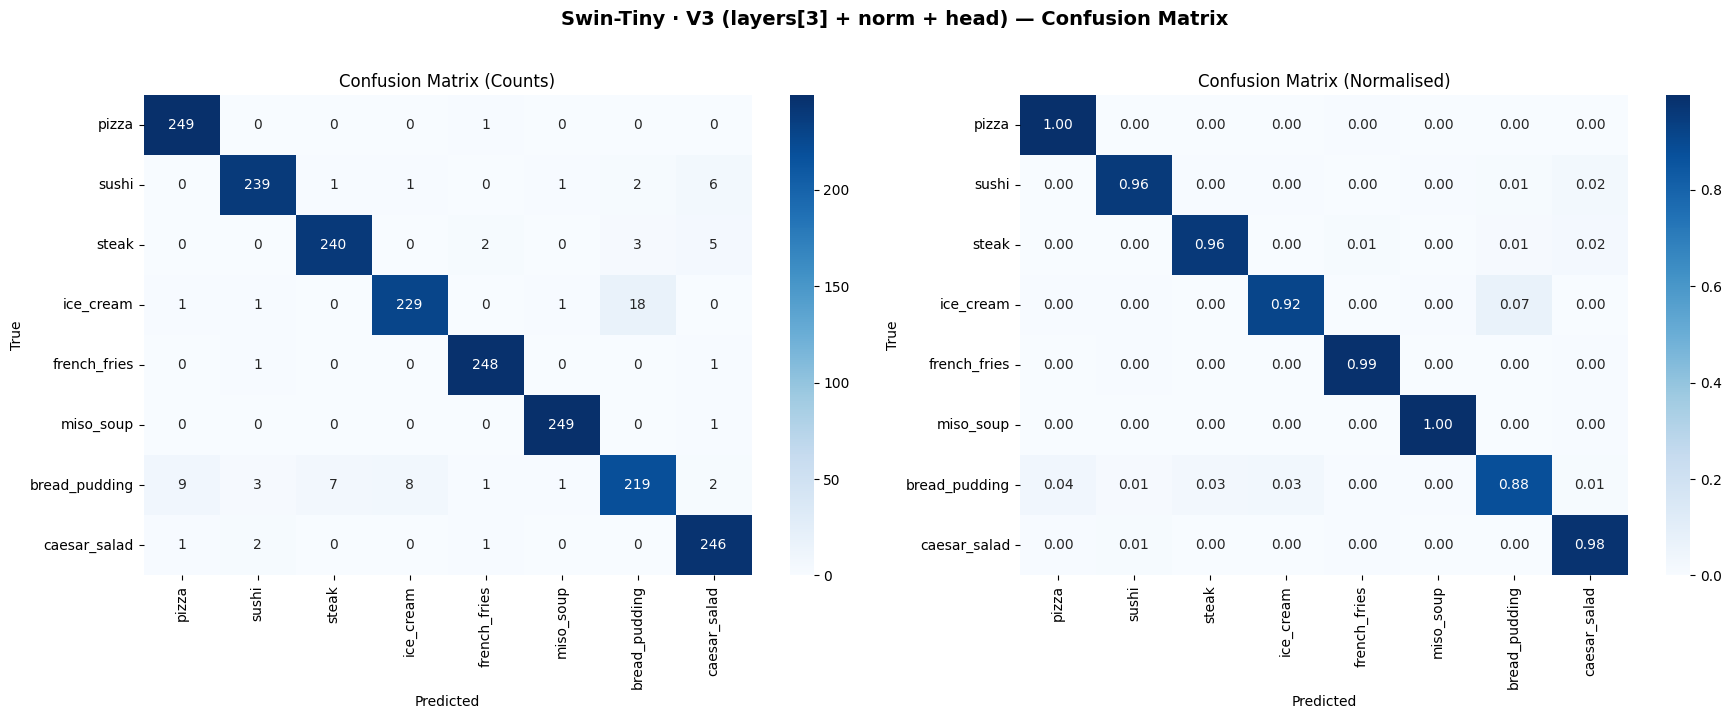

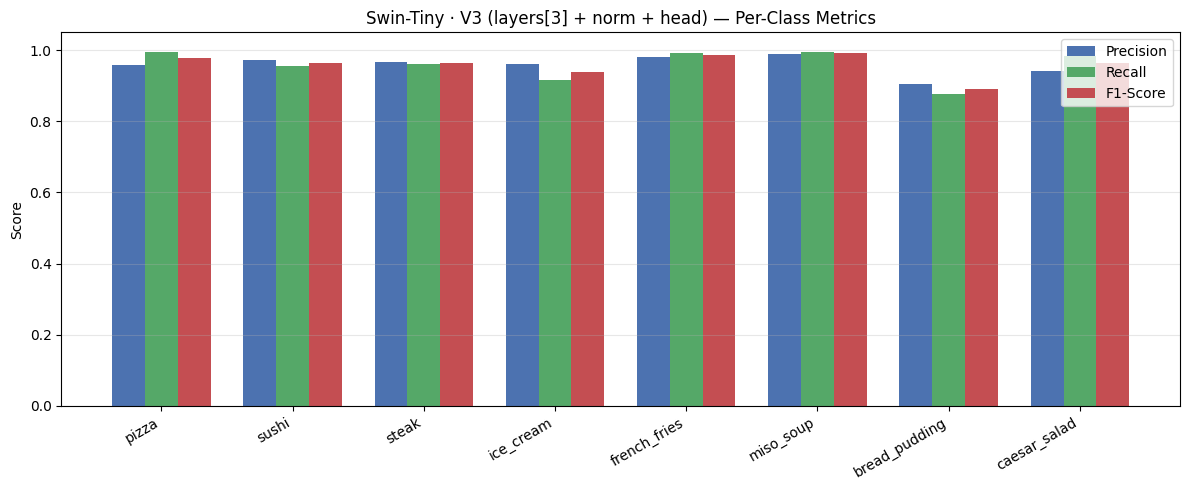


Classification Report:
               precision    recall  f1-score   support

        pizza     0.9577    0.9960    0.9765       250
        sushi     0.9715    0.9560    0.9637       250
        steak     0.9677    0.9600    0.9639       250
    ice_cream     0.9622    0.9160    0.9385       250
 french_fries     0.9802    0.9920    0.9861       250
    miso_soup     0.9881    0.9960    0.9920       250
bread_pudding     0.9050    0.8760    0.8902       250
 caesar_salad     0.9425    0.9840    0.9628       250

     accuracy                         0.9595      2000
    macro avg     0.9594    0.9595    0.9592      2000
 weighted avg     0.9594    0.9595    0.9592      2000

Checkpoint saved → ./swin-tiny__v3_layers[3]_+_norm_+_head.pth  (110.2 MB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [27]:
# V3: layers[3] scope (same as original V2) but LR 1e-4 + stronger weight decay
swin_v3 = build_swin_v3()
_orig_wd = WEIGHT_DECAY
WEIGHT_DECAY = 5e-4
results_swin_v3 = run_full_variation(
    swin_v3,
    run_name  = 'Swin-Tiny · V3 (layers[3] + norm + head)',
    lr        = LR_V3,
    num_epochs= EPOCHS_V3,
)
WEIGHT_DECAY = _orig_wd  # restore

---
## 7 · Results Comparison Table
Compare all 9 variations side-by-side.

In [28]:
# Collect all results
all_results = {
    'MobileNetV3 V1': results_mobilenet_v1,
    'MobileNetV3 V2': results_mobilenet_v2,
    'MobileNetV3 V3': results_mobilenet_v3,
    'EfficientNet V1': results_efficientnet_v1,
    'EfficientNet V2': results_efficientnet_v2,
    'EfficientNet V3': results_efficientnet_v3,
    'Swin-Tiny V1':   results_swin_v1,
    'Swin-Tiny V2':   results_swin_v2,
    'Swin-Tiny V3':   results_swin_v3,
}

print('=' * 105)
print(f'  {"Model":<22} {"Top-1":>8} {"Top-5":>8} {"Macro P":>9} {"Macro R":>9}'
      f' {"Macro F1":>9} {"Params (M)":>11} {"Time (ms)":>10}')
print('=' * 105)
for name, r in all_results.items():
    params_m = r['total_params'] / 1e6
    print(f'  {name:<22} {r["top1_acc"]:>8.4f} {r["top5_acc"]:>8.4f}'
          f' {r["macro_precision"]:>9.4f} {r["macro_recall"]:>9.4f}'
          f' {r["macro_f1"]:>9.4f} {params_m:>11.2f} {r["inference_time_ms"]:>10.3f}')
print('=' * 105)

best_name = max(all_results, key=lambda k: all_results[k]['top1_acc'])
best_r    = all_results[best_name]
print(f'\n★  Best variation: {best_name}')
print(f'   Top-1: {best_r["top1_acc"]:.4f}  |  Macro F1: {best_r["macro_f1"]:.4f}')

  Model                     Top-1    Top-5   Macro P   Macro R  Macro F1  Params (M)  Time (ms)
  MobileNetV3 V1           0.9035   0.9960    0.9059    0.9035    0.9038        4.21      0.723
  MobileNetV3 V2           0.9285   0.9980    0.9315    0.9285    0.9287        4.21      0.633
  MobileNetV3 V3           0.9435   0.9990    0.9454    0.9435    0.9434        4.21      0.676
  EfficientNet V1          0.8885   0.9965    0.8914    0.8885    0.8888        4.02      1.129
  EfficientNet V2          0.9130   0.9970    0.9145    0.9130    0.9132        4.02      1.138
  EfficientNet V3          0.9460   0.9965    0.9462    0.9460    0.9458        4.02      1.138
  Swin-Tiny V1             0.9385   0.9995    0.9403    0.9385    0.9384       27.53      4.649
  Swin-Tiny V2             0.9385   0.9995    0.9400    0.9385    0.9383       27.53      4.727
  Swin-Tiny V3             0.9595   0.9995    0.9594    0.9595    0.9592       27.53      4.622

★  Best variation: Swin-Tiny V3
   Top-

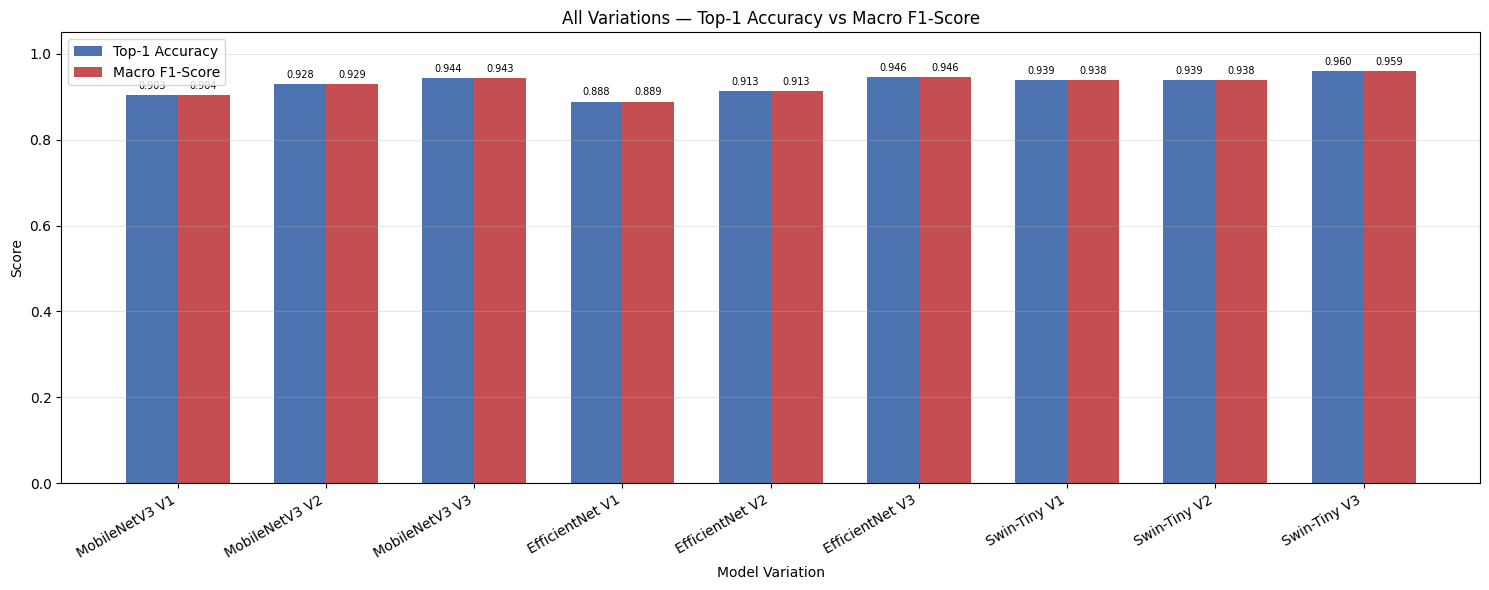

In [29]:
# Bar chart comparison of Top-1 accuracy and Macro F1
names    = list(all_results.keys())
top1s    = [all_results[n]['top1_acc'] for n in names]
macro_f1s= [all_results[n]['macro_f1'] for n in names]

x     = np.arange(len(names))
width = 0.35

fig, ax = plt.subplots(figsize=(15, 6))
bars1 = ax.bar(x - width/2, top1s,     width, label='Top-1 Accuracy', color='#4C72B0')
bars2 = ax.bar(x + width/2, macro_f1s, width, label='Macro F1-Score',  color='#C44E52')

ax.set_xlabel('Model Variation')
ax.set_ylabel('Score')
ax.set_title('All Variations — Top-1 Accuracy vs Macro F1-Score')
ax.set_xticks(x)
ax.set_xticklabels(names, rotation=30, ha='right')
ax.set_ylim(0, 1.05)
ax.legend()
ax.grid(True, axis='y', alpha=0.3)

for bar in bars1 + bars2:
    h = bar.get_height()
    ax.annotate(f'{h:.3f}',
                xy=(bar.get_x() + bar.get_width() / 2, h),
                xytext=(0, 3), textcoords='offset points',
                ha='center', va='bottom', fontsize=7)

plt.tight_layout()
plt.show()

---
## 8 · Best Variation — Detailed Report
Confusion matrix and classification report for the top-performing variation.

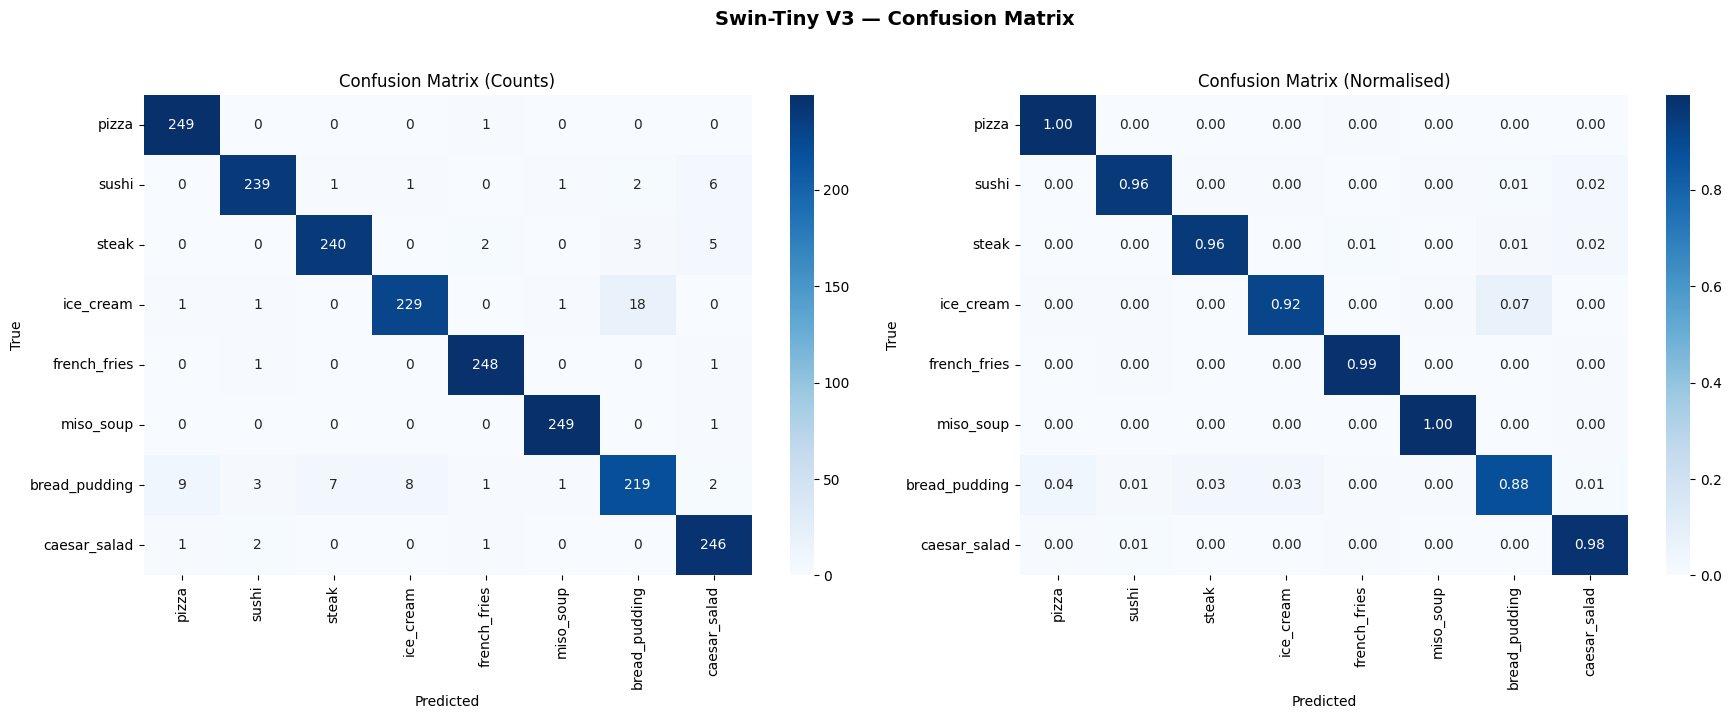

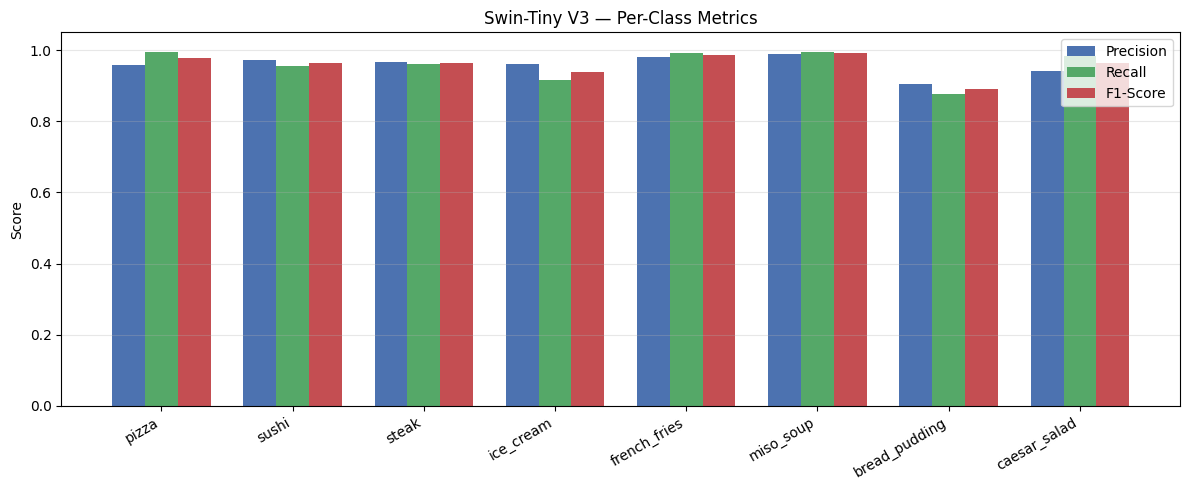


Classification Report — Swin-Tiny V3
               precision    recall  f1-score   support

        pizza     0.9577    0.9960    0.9765       250
        sushi     0.9715    0.9560    0.9637       250
        steak     0.9677    0.9600    0.9639       250
    ice_cream     0.9622    0.9160    0.9385       250
 french_fries     0.9802    0.9920    0.9861       250
    miso_soup     0.9881    0.9960    0.9920       250
bread_pudding     0.9050    0.8760    0.8902       250
 caesar_salad     0.9425    0.9840    0.9628       250

     accuracy                         0.9595      2000
    macro avg     0.9594    0.9595    0.9592      2000
 weighted avg     0.9594    0.9595    0.9592      2000



In [30]:
# Detailed plots for the best variation
plot_confusion_matrix(best_r, best_name)
plot_per_class_metrics(best_r, best_name)

print(f'\nClassification Report — {best_name}')
print(classification_report(
    best_r['all_labels'], best_r['all_preds'],
    target_names=CLASS_NAMES, digits=4
))

---
## 9 · Per-Architecture Summary
Best variation per architecture (useful for the final project report).

In [31]:
arch_groups = {
    'MobileNetV3': ['MobileNetV3 V1', 'MobileNetV3 V2', 'MobileNetV3 V3'],
    'EfficientNet-B0': ['EfficientNet V1', 'EfficientNet V2', 'EfficientNet V3'],
    'Swin-Tiny': ['Swin-Tiny V1', 'Swin-Tiny V2', 'Swin-Tiny V3'],
}

print('=' * 70)
print(f'  {"Architecture":<20} {"Best Variation":<22} {"Top-1":>8} {"Macro F1":>9}')
print('=' * 70)
for arch, variations in arch_groups.items():
    best_var  = max(variations, key=lambda k: all_results[k]['top1_acc'])
    best_arch = all_results[best_var]
    print(f'  {arch:<20} {best_var:<22}'
          f' {best_arch["top1_acc"]:>8.4f} {best_arch["macro_f1"]:>9.4f}')
print('=' * 70)

  Architecture         Best Variation            Top-1  Macro F1
  MobileNetV3          MobileNetV3 V3           0.9435    0.9434
  EfficientNet-B0      EfficientNet V3          0.9460    0.9458
  Swin-Tiny            Swin-Tiny V3             0.9595    0.9592
